# Imports & Constants

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
import ast
import contextlib
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import random
import seaborn as sns
import statsmodels.api as sm
import multiprocess as mp

In [4]:
from collections import defaultdict
from random import choices
from joblib import Parallel, delayed
from scipy import stats
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.tools.sm_exceptions import ConvergenceWarning, HessianInversionWarning
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.cross_decomposition import PLSRegression
from tqdm.notebook import tqdm
from typing import Optional
from matplotlib.colors import ListedColormap
from time import gmtime, strftime

In [5]:
from jupyter_utils import style, mean_std, display_test, display_group_test, \
    scatter_annotate, show_corrtest_mask_corr, pointplot, pointplot_horizontal, add_grey, \
    prep_horizontal_pointplot_errobar_data, pointplot_horizontal_wo_errorbar, map_model, prep_LM_pointplot, \
    draw_sample_with_replacement, t_test
from ortogonolize_utils import compute_coefficient

In [6]:
import warnings

warnings.filterwarnings(action="ignore")
warnings.simplefilter('ignore')

In [7]:
sns.set_theme(style="whitegrid")

In [8]:
PATH = '/Users/galina.ryazanskaya/Downloads/thesis?/code?/'

In [9]:
PATH_FIG = '/Users/galina.ryazanskaya/Downloads/thesis?/figures/ru/'

In [10]:
ERRORBAR = ('pi', 95)

In [11]:
DECIMAL = 7

1. mean sent len vs sent count vs word count
- is word count a good baseline?
- do other metrics correlate with it more than with mean sent len / sent count?

each group of metrcis:
- contorol:
    - 3 (2 * 2) panel correlation w control

- t + roc auc + llh ratio:
    - each task:
        - 3 * 2 pannel (corr: mean sent len vs sent count vs word count     +     3 * t-test)
        - line for each baseline on the respective t-test panel?
    - cross-task comparison:
        - average?
        - (2 * 2) panel t-test

- r + delta r squared + multivariate:
    - each task:
        - 3 * 3 pannel (corr: mean sent len vs sent count vs word count)    +    (6-panel scales)
        - each scale pannel has all the three baseline lines?
    - cross-task comparison:
        - average?
        - (2 * 2) panel for each scale


2. cross group metric comparison
- no filtering out based on the control correlation, only based on the performance
- the ones that correlate with some control above the threshold, make the marker different in the comparison

# Load data

In [12]:
merge_df = pd.read_csv('/Users/galina.ryazanskaya/Downloads/thesis?/code?/processed_values/ru_all.csv', index_col=0,
                       header=[0, 1, 2])

In [13]:
TASKS = ['adventure', 'chair', 'present', 'sportsman']

In [14]:
scale_cols = [('target', x) for x in ['panss_pos', 'panss_neg', 'panss_o', 'panss_total']]

In [15]:
cols_tasks = merge_df['sportsman'].columns
cols_LM = [col for col in merge_df['sportsman'] if col[0] == 'LM']
cols_synt = [col for col in merge_df['sportsman'] if col[0] == 'syntactic']
cols_lex = [col for col in merge_df['sportsman'] if col[0] == 'lexical']
cols_graph = [col for col in merge_df['sportsman'] if col[0] == 'graph']

In [16]:
def task_data(df, task, keep_target=True, fill_synt=True):
    subset = df[task].dropna(axis=0, how='all')
    if fill_synt:
        subset['syntactic'] = subset['syntactic'].fillna(0.0)  # fills NAs in missing POS
    if keep_target:
        subset = pd.concat([subset, df['target'].loc[subset.index]], axis=1)
    return subset

In [17]:
def apply_to_all_tasks(df, f, tasks=TASKS, to_df=True, remove_exception=False, *args, **kwargs):
    res = {}
    for task in tasks:
        if remove_exception and task == 'sportsman':  # If you are reading this, I am truly sorry
            data = task_data(df, task).drop(index=['PD127'])
        else:
            data = task_data(df, task)
        res[task] = f(data, *args, **kwargs)
    if to_df:
        if all(isinstance(v, pd.Series) for v in res.values()):
            return pd.DataFrame(res)
        elif all(isinstance(v, pd.DataFrame) for v in res.values()):
            return pd.concat(list(res.values()), keys=list(res.keys()), names=['task'], axis=1)
        else:
            return res
    return res

In [18]:
group_means = merge_df.drop(columns=[('target', 'target', 'diagnosis.group'), ('target', 'target', 'sex')]).groupby(
    [('target', 'target', 'diagnosis.type')]).mean().T
group_means.drop(columns=['control'], inplace=True)
group_means.columns = ['control', 'dep', 'NAP']
group_means.index.rename(['task', 'feature_group', 'feature'], inplace=True)
group_means.to_csv("feature_means_ru.csv")

### Bootstrap for each task
- sample with replacement (keep group proportions)
    1. compute r for each scale for each iteration (for all together, depression only, and psychosis only)
    2. compute t test for each iteration (for each group pair)
    3. compute ordered variable test (for all together and psychosis only)
    4. compute multivariate linear and logistic regression
    5. compute delta r2 wrt best verbosity metric
    6. compute ROC-AUC

In [19]:
# binarize sex
merge_df[('target', 'target', 'sex_binary')] = merge_df[('target', 'target','sex')].map({'female': 0, 'male': 1})

In [20]:
cols_to_test_additionally = [('lexical','LTR'), ('graph', 'LCC'), ('graph', 'number_of_edges'), ('syntactic', 'PART'), ('LM', 'glove_tf_lcoh'), ('LM', 'bert_pppl')]

In [21]:
default_covariates = [('target','sex_binary'), ('target','age'), ('target', 'education.years')]

In [22]:
# cols_tasks

In [23]:
def compute_OLS_rsquared(df, target_col, predictor_cols, round_decimal=DECIMAL):
    X = df[predictor_cols]
    y = df[[target_col]]
    ols = LinearRegression()
    ols.fit(X, y)
    r2 = ols.score(X, y)
    r_adjusted = 1 - (1 - r2) * (len(y) - 1) / (len(y) - X.shape[1] - 1)
    return np.round(r2, decimals=round_decimal), r_adjusted

In [24]:
def compute_OLS_rsquared_difference(df, target_col, predictor_cols, control_for_col, 
                                    default_covariates, r_control_only=None, round_decimal=DECIMAL):
    if r_control_only is None:
        r_control_only, _ = compute_OLS_rsquared(df, target_col, [control_for_col] + default_covariates, 
                                              round_decimal=round_decimal)
    r_pred_and_control, r_adj_pred_and_control = compute_OLS_rsquared(df, target_col, 
                                              [control_for_col] + default_covariates + predictor_cols, 
                                              round_decimal=round_decimal)
    r_pred_and_control = r_control_only if r_pred_and_control < -1000 else r_pred_and_control
    r_diff = r_pred_and_control - r_control_only
    r_diff = 0 if r_diff < 0 else r_diff
    
    # marginal model (single predictor, no covariates)
    r_marginal, _ = compute_OLS_rsquared(df, target_col, predictor_cols, round_decimal=round_decimal)
    
    return r_control_only, r_pred_and_control, r_diff, r_marginal, r_adj_pred_and_control

In [25]:
def group_select(df, test_two_groups, colname):
    return df[df[('target', colname)].isin(test_two_groups)]

In [26]:
def compute_roc_auc(df_groups, target_col, predictor_column):
#     df_groups = df_groups.loc[df_groups[[target_col, predictor_column]].dropna().index]
    X = df_groups[[predictor_column]]
    y = df_groups[[target_col]]
    clf = LogisticRegression(solver="newton-cholesky", random_state=0, penalty=None)
    clf.fit(X, y)
    y_pred_prob = clf.predict_proba(X)
    return roc_auc_score(y, y_pred_prob[:, 1])

In [27]:
def compute_logistic_llh(df_groups, target_col, predictor_cols, round_decimal=DECIMAL):
#     df_groups = df_groups.loc[df_groups[[target_col] + predictor_cols].dropna().index]
    X = df_groups[predictor_cols]
    y = df_groups[[target_col]]
    clf = LogisticRegression(solver="newton-cholesky", random_state=0, penalty=None)
    clf.fit(X, y)
    y_pred_prob = clf.predict_proba(X)
    # accuracy 
    # clf.score(X, y)
    return np.round(-log_loss(y, y_pred_prob, normalize=False), decimals=round_decimal) #, y_pred_prob, y

In [28]:
def compute_logistic_llh_null(df_groups, target_col, round_decimal=DECIMAL):
    y = df_groups[target_col].values
    classes = np.unique(y)  # sorted by numpy, same as sklearn convention
    n = len(y)
    counts = {c: (y == c).sum() for c in classes}
    llh_null = sum(
        count * np.log(count / n) 
        for count in counts.values() 
        if count > 0
    )
    return np.round(llh_null, decimals=round_decimal)

In [29]:
# McFadden's adjusted pseudo-R²
# https://www.statease.com/docs/v23.0/contents/advanced-topics/glm/adj-mcfadden-pseudo-r-squared/
def compute_ps_r_adj_llh(sample_llh_null, sample_llh_to_correct, k):
    return 1 - (sample_llh_to_correct - k) / sample_llh_null

In [30]:
def logistic_llh_difference(df_groups, target_col, predictor_cols, control_for_col, 
                            default_covariates, llh_control_only=None, llh_null=None,
                            round_decimal=DECIMAL):
    # control model (verbosity + default covariates)
    if llh_control_only is None:
        llh_control_only = compute_logistic_llh(
            df_groups, target_col, [control_for_col] + default_covariates, 
            round_decimal=round_decimal
        )
    
    # full model
    llh_pred_and_control = compute_logistic_llh(
        df_groups, target_col, 
        [control_for_col] + default_covariates + predictor_cols, 
        round_decimal=round_decimal
    )
    
    # LLH difference (full model vs control model)
    llh_diff = 2 * (llh_pred_and_control - llh_control_only) # likelihood ratio statistic
    llh_diff = 0 if llh_diff < 0 else llh_diff
    
    # intercept-only model
    if llh_null is None:
        llh_null = compute_logistic_llh_null(df_groups, target_col, round_decimal=round_decimal)
    # marginal model (single predictor, no covariates)
    llh_marginal = compute_logistic_llh(
        df_groups, target_col, predictor_cols, 
        round_decimal=round_decimal
    )
    llh_marginal_diff = 2 * (llh_marginal - llh_null)
    # NEW
    llh_marginal_diff = 0 if llh_marginal_diff < 0 else llh_marginal_diff

    ps_r_adj = compute_ps_r_adj_llh(llh_null, llh_pred_and_control, k=len([control_for_col] + default_covariates + predictor_cols))
    
    return llh_control_only, llh_pred_and_control, llh_diff, llh_marginal_diff, ps_r_adj

In [31]:
def drop_na_in_cols(df, cols):
    return df.loc[df[cols].dropna().index]

added at review:
- Logistic and AUC
  - (1) Logistic r2 and AUC for verbosity (and default covariates)
  - (2) Logistic r2 and AUC multi-metric model (promising metrics only) (and default covariates)
  - (3).x Logistic r2 and AUC for each metric (and default covariates)
  - (4) difference in r2 for verbosity and multi-metric model (1) - (2)
  - (5) difference in r2 for verbosity and each metric (1) - (3).x 
      
- optimize: compute each model only as many times as necessary
  - how could data be pre-selected?
  - PLS
      - (1) PLS r2 for panss_total for verbosity (and default covariates)
      - (2) PLS r2 for panss_total for multi-metric model (and default covariates)
      - (3).x PLS r2 for panss_total for each promising metric (and default covariates)
      - (4) difference in r2 for verbosity and multi-metric model (1) - (2)
      - (5) difference in r2 for verbosity and each promising metric (1) - (3).x
- integrate into bootsrap iteration

In [32]:
## detect NaNs
# ex_df[('target', )][ex_df[('target', )].isna().any(axis=1)].index

In [33]:
## detect NaNs
# for col in ex_df.columns:
#     if col not in cols_tasks:
#         continue
#     nan_rows = ex_df[ex_df[col].isna()].index.tolist()
#     for row in nan_rows:
#         print(row, col)

In [34]:
## detect NaNs
# for task in TASKS:
#     print(task)
#     ex_df = task_data(merge_df, task)
#     for col in ex_df.columns:
#         if col not in cols_tasks:
#             continue
#         nan_rows = ex_df[ex_df[col].isna()].index.tolist()
#         for row in nan_rows:
#             print(row, col)

## Bootstrap

In [35]:
def compute_pseudo_rsquared_ordered(df, target_col, predictor_cols):
    df = df.loc[df[[target_col] + predictor_cols].dropna().index]
    mod_prob = OrderedModel(df[target_col],
                            df[predictor_cols],
                            distr='probit')

    res_prob = mod_prob.fit(method='bfgs', disp=0)
    return res_prob.prsquared

In [36]:
a = 0.05

In [37]:
def ttest(groups_df, target_col, cols_tasks=cols_tasks):
    s_t, res_t = display_group_test(groups_df, cols_tasks, target_col, test=stats.ttest_ind, stat_name='t',
                                    alpha=a)
    return res_t['t']

In [38]:
cols_to_correct_for = [('syntactic', 'mean_sent_len'), ('syntactic', 'n_sents'), ('lexical', 'n_words')]

In [39]:
best_verbosity_metric = ('lexical', 'n_words')

In [40]:
# merge_df[merge_df[('target', 'target', 'diagnosis.type')] == 'sz'][('target', 'target', 'panss_total')]
# PD009
# PD097

In [41]:
def try_bootstrap_iteration(sample: pd.DataFrame,
                            group: str,
                            cols_av: list[tuple[str, str]],
                            scale_cols: list[tuple[str, str]],
                            columns_to_correct_for: list[tuple[str, str]],
                            best_verbosity_metric: tuple[str, str],
                            default_covariates: list[tuple[str, str]],
                            cols_to_test_additionally: list[tuple[str, str]],
                            target_col_corr: list[tuple[str, str]],
                            ordered_tgt: list[tuple[str, str]]) -> dict[tuple[str, str, str], float]:
    # we need to put scale_independent into each scale outside this function to comly with the old format
    iteration_result: dict[tuple[str, str, str], float] = {}  # (target, scale, column) : metric
    
    columns_for_corr = cols_av + scale_cols
    group_target_col = ('target', group)
    
    # groups
    sample_sz = sample[sample[group_target_col] == 'sz']
    sample_dep = sample[sample[group_target_col] == 'dep']
    
    sample_no_NaNs = drop_na_in_cols(sample, default_covariates)
    sample_sz_no_NaNs = drop_na_in_cols(sample_no_NaNs[sample_no_NaNs[group_target_col] == 'sz'], 
                                        [target_col_corr])
    
    paired_suffix = {'': ('sz', 'control_psy'),
                    '_sz_dep' : ('sz', 'dep'),
                    '_dep': ('dep', 'control_psy')}
    paired_sample = {}
    paired_sample_no_NaNs = {}
    paired_ttest = {}
    paired_best_verbosity_logistic_r = {}
    paired_llh_null = {} # NEW
    for suffix, group_pair in paired_suffix.items():
        grouped_sample = group_select(sample, group_pair, group)
        paired_sample[suffix] = grouped_sample
        
        # ttest
        paired_ttest[suffix] = ttest(grouped_sample, group_target_col, cols_tasks=cols_av)
        
        grouped_sample_no_NaNs = group_select(sample_no_NaNs, group_pair, group)
        paired_sample_no_NaNs[suffix] = grouped_sample_no_NaNs
        # null (intercept-only) logistic log likelihood
        llh_null = compute_logistic_llh_null(grouped_sample_no_NaNs, group_target_col)
        paired_llh_null[suffix] = llh_null          
        
        # best verbosity logistic log likelihood 
        bvlr = compute_logistic_llh(grouped_sample_no_NaNs, group_target_col,
                                         [best_verbosity_metric] + default_covariates)
        paired_best_verbosity_logistic_r[suffix] = bvlr
        bvlr_ps_r_adj = compute_ps_r_adj_llh(llh_null, bvlr, k=len([best_verbosity_metric] + default_covariates))
        iteration_result[(f'llh_lr_bv{suffix}', 'scale_independent', ('overview', 'col_independent'))] = bvlr_ps_r_adj
        
        # default covariates logistic log likelihood 
        dclr = compute_logistic_llh(grouped_sample_no_NaNs, group_target_col, default_covariates)
        dclr_ps_r_adj = compute_ps_r_adj_llh(llh_null, dclr, k=len(default_covariates))
        iteration_result[(f'llh_lr_dc{suffix}', 'scale_independent', ('overview', 'col_independent'))] = dclr_ps_r_adj
        

    # corrs
    corr_res = (sample[columns_for_corr]
                .corr(method='pearson')
                .sort_index(level=list(range(2)))
                .sort_index(axis=1, level=list(range(2))))

    corr_res_sz_only = (sample_sz[columns_for_corr]
                        .corr(method='pearson')
                        .sort_index(level=list(range(2)))
                        .sort_index(axis=1, level=list(range(2))))

    corr_res_dep_only = (sample_dep[columns_for_corr]
                    .corr(method='pearson')
                    .sort_index(level=list(range(2)))
                    .sort_index(axis=1, level=list(range(2))))
    
    # Multivar
    # Logistic regression log likelihood
    multivarlr = compute_logistic_llh(paired_sample_no_NaNs[''], 
                                           group_target_col,
                                           [best_verbosity_metric] + 
                                           default_covariates + cols_to_test_additionally)
    multivar_ps_r_adj = compute_ps_r_adj_llh(llh_null, multivarlr, k=len([best_verbosity_metric] + 
                                             default_covariates + cols_to_test_additionally))
    iteration_result[(f'llh_lr_multi', 'scale_independent', ('overview', 'col_independent'))] = multivar_ps_r_adj
    
    # Multivar
    # OLS
    multivarols, multivar_ols_adj = compute_OLS_rsquared(sample_sz_no_NaNs, target_col_corr,
                                       [best_verbosity_metric] + 
                                       default_covariates + cols_to_test_additionally)
    iteration_result[(f'r_ols_multi', target_col_corr, ('overview', 'col_independent'))] = multivar_ols_adj
    
    # OLS single best predcitor
    bvols, bv_ols_adj = compute_OLS_rsquared(sample_sz_no_NaNs, target_col_corr, [best_verbosity_metric] + default_covariates)
    iteration_result[(f'r_ols_bv', target_col_corr, ('overview', 'col_independent'))] = bv_ols_adj
    
    # OLS single default covariates
    dcols, dc_ols_adj = compute_OLS_rsquared(sample_sz_no_NaNs, target_col_corr, default_covariates)
    iteration_result[(f'r_ols_dc', target_col_corr, ('overview', 'col_independent'))] = dc_ols_adj


    for col in cols_av:
        for suffix in paired_suffix:
            # ttest
            iteration_result[(f't{suffix}', 'scale_independent', col)] = paired_ttest[suffix][col]
            # auc
            grouped_sample = paired_sample[suffix]
            iteration_result[(f'auc{suffix}', 'scale_independent', col)] = compute_roc_auc(grouped_sample, 
                                                                                            group_target_col, col)
            # Logistic regression incremental improvement
            if col == best_verbosity_metric:
                continue
            grouped_sample_no_NaNs = paired_sample_no_NaNs[suffix]
            # (verbosity only)
            best_verbosity_r = paired_best_verbosity_logistic_r[suffix]
            
            _, r_v_c, r_diff, r_marginal_diff, ps_r_adj = logistic_llh_difference(
                                                        grouped_sample_no_NaNs, group_target_col, 
                                                        [col], best_verbosity_metric, default_covariates, 
                                                        llh_control_only=best_verbosity_r,
                                                        llh_null=paired_llh_null[suffix]) 
            # (verbosity + metric) - (verbosity only)
            iteration_result[(f'llh_lr_diff{suffix}', 'scale_independent', col)] = r_diff
            # (verbosity + metric)
            iteration_result[(f'llh_lr_bv_m{suffix}', 'scale_independent', col)] = ps_r_adj  
            # (metric alone) - (intercept only)
            iteration_result[(f'llh_lr_marginal_diff{suffix}', 'scale_independent', col)] = r_marginal_diff

    
        for col_to_correct_for in columns_to_correct_for:
            if col == col_to_correct_for:
                continue
            # corr w control columns
            r_c = corr_res.loc[col, col_to_correct_for]
            iteration_result[(f'r_corr_w_{col_to_correct_for[-1]}', 'scale_independent', col)] = r_c
            r_c_sz = corr_res_sz_only.loc[col, col_to_correct_for]
            iteration_result[(f'r_corr_w_{col_to_correct_for[-1]}_sz', 'scale_independent', col)] = r_c_sz
            r_c_dep = corr_res_dep_only.loc[col, col_to_correct_for]
            iteration_result[(f'r_corr_w_{col_to_correct_for[-1]}_dep', 'scale_independent', col)] = r_c_dep

        for tgt in ordered_tgt:
            ps_r = compute_pseudo_rsquared_ordered(sample, tgt, [col])
            iteration_result[(f'ps_r_{tgt[1]}', 'scale_independent', col)] = ps_r

            ps_r_sz = compute_pseudo_rsquared_ordered(sample_sz, tgt, [col])
            iteration_result[(f'ps_r_{tgt[1]}_sz', 'scale_independent', col)] = ps_r_sz

            # ps_r_dep = compute_pseudo_rsquared_ordered(sample_dep, tgt, [col])
            # iteration_result[(f'ps_r_{tgt[1]}_dep', 'scale_independent', col)] = ps_r_dep
            ## canot work as the results are too often identical when bootstrapping

        for scale in scale_cols:
            # corr w scales
            iteration_result[('r', scale, col)] = corr_res.loc[col, scale]
            iteration_result[('r_sz', scale, col)] = corr_res_sz_only.loc[col, scale]
            iteration_result[('r_dep', scale, col)] = corr_res_dep_only.loc[col, scale]
            if scale != target_col_corr:
                continue
            if col == best_verbosity_metric:
                continue
            _, r_v_c, r_diff, r_marginal, r_adj = compute_OLS_rsquared_difference(  # CHANGED
                                                   sample_sz_no_NaNs, 
                                                   target_col_corr, 
                                                   [col], 
                                                   best_verbosity_metric, 
                                                   default_covariates, 
                                                   bvols)
            # (verbosity + metric) - (verbosity only)
            iteration_result[(f'r_ols_diff', target_col_corr, col)] = r_diff
            # (verbosity + metric)
            iteration_result[(f'r_ols_bv_m', target_col_corr, col)] = r_adj
            # (metric alone)                                                          
            iteration_result[(f'r_ols_marginal', target_col_corr, col)] = r_marginal

    return iteration_result

In [42]:
def bootstrap_iteration(sample: pd.DataFrame,
                        group: str,
                        cols_av: list[tuple[str, str]],
                        scale_cols: list[tuple[str, str]],
                        columns_to_correct_for: list[tuple[str, str]],
                        best_verbosity_metric: tuple[str, str],
                        default_covariates: list[tuple[str, str]],
                        cols_to_test_additionally: list[tuple[str, str]],
                        target_col_corr: list[tuple[str, str]],
                        ordered_tgt: list[tuple[str, str]]) -> Optional[dict[tuple[str, str, str], float]]:
    warnings.filterwarnings(action="ignore")
    warnings.simplefilter('ignore')
    return try_bootstrap_iteration(sample, group, cols_av, scale_cols, columns_to_correct_for, 
                                   best_verbosity_metric, default_covariates, cols_to_test_additionally, 
                                   target_col_corr, ordered_tgt)

In [43]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""

    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [44]:
def bootstrap_parallel(df: pd.DataFrame,
                       N: int,
                       group: str,
                       cols_av: list[tuple[str, str]],
                       scale_cols: list[tuple[str, str]],
                       columns_to_correct_for: list[tuple[str, str]],
                       best_verbosity_metric: tuple[str, str],
                       default_covariates: list[tuple[str, str]],
                       cols_to_test_additionally: list[tuple[str, str]],
                       target_col_corr: list[tuple[str, str]],
                       ordered_tgt: list[tuple[str, str]]) -> list[dict[tuple[str, str, str], float]]:
    results = []
    seed = 0
    while len(results) < N:
        total = N - len(results)
        presampled = [draw_sample_with_replacement(df, seed=seed + i, group_col=('target', group)) for i in
                      range(total)]
        with tqdm_joblib(tqdm(desc='progress', total=total)) as progress_bar:
            results_w_none = Parallel(n_jobs=-1)(
                delayed(bootstrap_iteration)(sample, group, cols_av, scale_cols, columns_to_correct_for, 
                                             best_verbosity_metric, default_covariates, 
                                             cols_to_test_additionally, target_col_corr, ordered_tgt)
                for sample in presampled)
        results.extend(filter(lambda x: x is not None, results_w_none))
        seed += N
    return results

takes a while to compute

In [45]:
# # an example for testing
# N = 3
# dict_scales_unprocessed_samples = apply_to_all_tasks(merge_df, bootstrap_parallel, remove_exception=True, N=N, cols_av=list(cols_tasks), 
#                             scale_cols=scale_cols, columns_to_correct_for=cols_to_correct_for, 
#                             group='diagnosis.type', 
#                             best_verbosity_metric=best_verbosity_metric, 
#                             default_covariates=default_covariates, 
#                             cols_to_test_additionally=cols_to_test_additionally, 
#                             target_col_corr=('target', 'panss_total'),
#                             ordered_tgt=[('target', 'dep.severity'),('target', 'td.severity')]
#                            )

In [46]:
# # # new procedure
# N = 1000
# # test_df = merge_df.drop(index=['PD127'])
# # TODO investigate missing tasks?????????????
# dict_scales_unprocessed_samples = apply_to_all_tasks(merge_df, bootstrap_parallel, remove_exception=True, N=N, cols_av=list(cols_tasks), 
#                             scale_cols=scale_cols, columns_to_correct_for=cols_to_correct_for, 
#                             group='diagnosis.type', 
#                             best_verbosity_metric=best_verbosity_metric, 
#                             default_covariates=default_covariates, 
#                             cols_to_test_additionally=cols_to_test_additionally, 
#                             target_col_corr=('target', 'panss_total'),
#                             ordered_tgt=[]
# #                             ordered_tgt=[('target', 'dep.severity'),('target', 'td.severity')]
#                            )

In [47]:
# # new procedure
# measures = set(measure for measure, scale, metric in dict_scales_unprocessed_samples['sportsman'][0].keys())

# reform = {key: {metric: [] for metric in list(cols_tasks) + [('overview', 'col_independent')]} for key in
#           [(task, scale[1], measure) for task in TASKS for scale in scale_cols for measure in measures]}
# for task, task_data_ in dict_scales_unprocessed_samples.items():
#     for item in task_data_:  # 1000 examples, we need to create lists of length 1000 instead
#         for measure, scale, metric in item.keys():
#             value = item[(measure, scale, metric)]
#             if scale == 'scale_independent':  # put scale_independent into each scale
#                 for _, scale_ in scale_cols:
#                     reform[(task, scale_, measure)][metric].append(value)
#             else:
#                 reform[(task, scale[1], measure)][metric].append(value)

In [48]:
# # new procedure
# with open(f'processed_values/ru_task_scales_samples_1000_w_verbosity_separate_reform_w_dep_w_multi_r_adj.pickle', 'wb') as f:
#     pickle.dump(reform, f)

In [49]:
# with new multivariate metrics + regressions
with open(f'processed_values/ru_task_scales_samples_1000_w_verbosity_separate_reform_w_dep_w_multi_r_adj.pickle', 'rb') as f:
    reform = pickle.load(f)

In [50]:
with open('processed_values/ru_task_scales_samples_1000_wo_o.pickle', 'rb') as f:
    reform_wo_o = pickle.load(f)

In [51]:
# old procedure with ordered regressions
with open(f'processed_values/ru_task_scales_samples_1000_w_verbosity_separate_reform_w_dep.pickle', 'rb') as f:
    reform_ = pickle.load(f)

In [52]:
panss_order = ['panss_pos', 'panss_neg', 'panss_o', 'panss_total']

# Plot & Analyze

In [53]:
reformed_d = pd.DataFrame(reform_)

In [54]:
panss_ = ('panss_pos', 'panss_neg', 'panss_o', 'panss_total')
sc_ind_ = ('t', 'r_corr_w_control', 'ps_r_dep.severity', 'ps_r_td.severity')
models_ = ('bert', 'glove_tf', 'glove_avg', 'w2v_tf', 'w2v_avg')
metrics_ = ('cgcoh', 'gcoh', 'lcoh', 'scoh', 'sprob', 'pppl')

In [55]:
order = ['bert', 'glove_tf', 'glove_avg', 'w2v_tf', 'w2v_avg']

In [56]:
figprms = {'syntactic':
               {'subplot_size': (9, 4.5),
                'wspace': 0.25,
                'hspace': 0.125,
                'yt': 0.925
                },
           'LM':
               {'subplot_size': (9, 5.5),
                'wspace': 0.275,
                'hspace': 0.125,
                'yt': 0.925
                },
           'lexical':
               {'subplot_size': (9, 2),
                'wspace': 0.2,
                'hspace': 0.3,
                'yt': 0.95
                },
           'graph':
               {'subplot_size': (9, 3.5),
                'wspace': 0.3,
                'hspace': 0.15,
                'yt': 0.95
                }}

In [57]:
def get_fparams(m_type, n_sublots_height, n_sublots_width, figparams):
    subplot_size = figprms[m_type]['subplot_size']
    width = subplot_size[0] * n_sublots_width
    height = subplot_size[1] * n_sublots_height
    figsize = (width, height)
    wspace = figprms[m_type]['wspace']
    hspace = figprms[m_type]['hspace']
    yt = figprms[m_type]['yt']
    return figsize, wspace, hspace, yt

### Plot horizontal bar plots

In [58]:
def plot_horizontal_tasks(df, title, scale, measure, xname=None, m_type='syntactic',
                          plot_abs=False, r=0.3, figparams=figprms, errorbar=ERRORBAR):
    absolute_value = f' (absolute r value)' if plot_abs else ''
    figsize, wspace, hspace, yt = get_fparams(m_type, 2, 2, figparams)
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    fig.suptitle(title + absolute_value, y=yt)
    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    axs = axes.flatten()

    for i, task in enumerate(TASKS):
        ax = axs[i]
        pointplot_horizontal(prep_horizontal_pointplot_errobar_data(df.loc[m_type, (task, scale)],
                                                                    col=measure, plot_abs=plot_abs),
                             x=measure, ax=ax, errorbar=errorbar)
        ax.set_title(task)

    add_grey(axes, r=r)
    if xname is None:
        xname = measure

    for ax in axes.reshape(-1):
        label = 'abs ' + xname if plot_abs else xname
        ax.set_xlabel(label)
    return fig

In [59]:
verbosity_control_cols = ['r_corr_w_mean_sent_len', 'r_corr_w_n_sents', 'r_corr_w_n_words']

In [60]:
control_col_names = ['mean sentence length', 'sentence count', 'word count']

In [61]:
_ =     fig = plot_horizontal_tasks(reformed_d, f'cross-task comparison for graph metrics on group difference between control and psychosis (t-test)',
                                scale='panss_o', measure='t', m_type='graph', r=2, figparams=figprms.copy(), errorbar=ERRORBAR)

In [62]:
_ =     fig = plot_horizontal_tasks(reformed_d, f'cross-task comparison for graph metrics on group difference between psychosis and depression (t-test)',
                                scale='panss_o', measure='t_sz_dep', m_type='graph', r=2, figparams=figprms.copy(), errorbar=ERRORBAR)

In [63]:
_ =     fig = plot_horizontal_tasks(reformed_d, f'cross-task comparison for graph metrics on group difference between control and depression (t-test)',
                                scale='panss_o', measure='t_dep', m_type='graph', r=2, figparams=figprms.copy(), errorbar=ERRORBAR)

In [64]:
_ = plot_horizontal_tasks(reformed_d, f'cross-task comparison for graph metrics on panss_total (r_sz)',
                                    scale='panss_total', measure='r_sz',
                                    m_type='graph', figparams=figprms.copy(), errorbar=ERRORBAR)

In [65]:
_ = plot_horizontal_tasks(reformed_d, f'cross-task comparison for graph metrics on panss_total (r)',
                                    scale='panss_total', measure='r',
                                    m_type='graph', figparams=figprms.copy(), errorbar=ERRORBAR)

In [66]:
_ = plot_horizontal_tasks(reformed_d, f'cross-task comparison for graph (r_sz) metrics on correlation with mean sentence length',
                                    scale='panss_total', measure='r_corr_w_mean_sent_len_sz',
                                    xname='r_sz', m_type='graph', figparams=figprms.copy(), errorbar=ERRORBAR)

In [67]:
def plot_all_scales(reformed_d, m_type='syntactic', path=PATH_FIG, plot_abs=True, dpi=150, figparams=figprms,
                    control_cols=['r_corr_w_control'], control_col_names=['mean sentence length'], sz=False, errorbar=ERRORBAR):
    for t, t_name in [('t', 'control and psychosis'), ('t_sz_dep', 'depression and psychosis'), ('t_dep', 'control and depression')]:
        fig = plot_horizontal_tasks(reformed_d,
                                    f'cross-task comparison for {m_type} metrics on group difference between {t_name} (t-test)',
                                    scale='panss_o', measure=t, m_type=m_type, r=2, figparams=figparams, errorbar=errorbar)
        plt.savefig(f'{path}{m_type}/{t}.png', dpi=dpi, bbox_inches='tight')
        plt.close(fig)

    ab = 'abs_' if plot_abs else ''
    sz_ = '_sz' if sz else ''
    sz_name = '(psychosis only)' if sz else '(all)'

    upfig = figparams.copy()
    if m_type == 'lexical':
        upfig[m_type]['yt'] += 0.05
    if len(control_cols) != len(control_col_names):
        raise ValueError('The names of the columns must match the columns in length.')
    for i, control_col in enumerate(control_cols):
        name = control_col_names[i]
        fig = plot_horizontal_tasks(reformed_d,
                                    f'cross-task comparison for {m_type} metrics on correlation with {name} {sz_name}',
                                    scale='panss_o', measure=control_col + sz_,
                                    xname='r' + sz_, m_type=m_type, figparams=upfig, errorbar=errorbar)
        plt.savefig(f'{path}{m_type}/{ab}corr_{"_".join(name.split())}{sz_}.png', dpi=dpi, bbox_inches='tight')
        plt.close(fig)

    for panss_scale in panss_order:
        fig = plot_horizontal_tasks(reformed_d,
                                    f'cross-task comparison for {m_type} metrics on {panss_scale} {sz_name}',
                                    scale=panss_scale, measure='r' + sz_,
                                    plot_abs=plot_abs, m_type=m_type, figparams=figparams, errorbar=errorbar)
        plt.savefig(f'{path}{m_type}/{ab}r_{panss_scale}{sz_}.png', dpi=dpi, bbox_inches='tight')
        plt.close(fig)

    fig = plot_horizontal_tasks(reformed_d,
                                f'cross-task comparison for {m_type} metrics of pseudo r squared for dep severity {sz_name}',
                                scale='panss_o', measure='ps_r_dep.severity' + sz_,
                                m_type=m_type, xname='pseudo r squared', r=0.09, figparams=figparams, errorbar=errorbar)
    plt.savefig(f'{path}{m_type}/ps_r_dep_severity{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)


    fig = plot_horizontal_tasks(reformed_d,
                                f'cross-task comparison for {m_type} metrics of pseudo r squared for td severity {sz_name}',
                                scale='panss_o',
                                measure='ps_r_td.severity' + sz_,
                                m_type=m_type, xname='pseudo r squared', r=0.09, figparams=figparams, errorbar=errorbar)
    plt.savefig(f'{path}{m_type}/ps_r_td_severity{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)

In [68]:
for m_type in reformed_d.index.unique(level=0):
    for sz in [False, True]:
        for plot_abs in [False, True]:
            plot_all_scales(reformed_d, m_type, plot_abs=plot_abs, control_cols=verbosity_control_cols,control_col_names=control_col_names, sz=sz)

### Plot vertical bar plots for LMs

In [70]:
def plot_lm_tasks(df, title, scale, measure, order=order, plot_abs=False, use_errorbar=True,
                  figsize=(15, 10), yname=None, r=0.3, errorbar=ERRORBAR):
    absolute_value = f' (absolute {measure} value)' if plot_abs else ''
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=True)
    fig.suptitle(title + absolute_value, y=0.925)
    plt.subplots_adjust(wspace=0.1)

    axs = axes.flatten()
    for i, task in enumerate(TASKS):
        ax = axs[i]
        d = prep_LM_pointplot(df.loc['LM', (task, scale)], col=measure, plot_abs=plot_abs)
        pointplot(d, x='model', y=measure, hue='metric', ax=ax, order=order, use_errorbar=use_errorbar, errorbar=errorbar)
        ax.set_title(task)

    add_grey(axes, line_dir='h', r=r)

    if yname is None:
        yname = measure
    for ax in axes.reshape(-1):
        label = 'abs ' + yname if plot_abs else yname
        ax.set_ylabel(label)
    return fig

In [71]:
def plot_all_LM(reformed_d, m_type='LM', path=PATH_FIG, plot_abs=False, figsize=(18, 12), dpi=150,
                control_cols=['r_corr_w_control'], control_col_names=['mean sentence length'], sz=False, errorbar=ERRORBAR):
    ab = 'abs_' if plot_abs else ''
    absolute_value = f' (absolute r value)' if plot_abs else ''
    sz_ = '_sz' if sz else ''
    sz_name = '(psychosis only)' if sz else '(all)'
    if len(control_cols) != len(control_col_names):
        raise ValueError('The names of the columns must match the columns in length.')

    for t, t_name in [('t', 'control and psychosis'), ('t_sz_dep', 'depression and psychosis'), ('t_dep', 'control and depression')]:
        fig = plot_lm_tasks(reformed_d,
                            f'cross-task comparison for LM metrics across models on group difference between {t_name} (t-test)',
                            scale='panss_o', measure=t, use_errorbar=True, figsize=figsize, r=2, errorbar=errorbar)
        plt.savefig(f'{path}{m_type}/model/{t}.png', dpi=dpi, bbox_inches='tight')
        plt.close(fig)

    for i, control_col in enumerate(control_cols):
        name = control_col_names[i]
        fig = plot_lm_tasks(reformed_d,
                            f'cross-task comparison for LM metrics across models on correlation with {name} {sz_name}',
                            scale='panss_o', measure=control_col + sz_, yname='r' + sz_,
                            plot_abs=plot_abs, use_errorbar=True, figsize=figsize, errorbar=errorbar)
        plt.savefig(f'{path}{m_type}/model/{ab}corr_{"_".join(name.split())}{sz_}.png', dpi=dpi, bbox_inches='tight')
        plt.close(fig)

    for panss_scale in panss_:
        fig = plot_lm_tasks(reformed_d,
                            f'cross-task comparison for LM metrics across models on {panss_scale}{absolute_value} {sz_name}',
                            scale=panss_scale, measure='r' + sz_,
                            plot_abs=plot_abs, use_errorbar=True, figsize=figsize, errorbar=errorbar)
        plt.savefig(f'{path}{m_type}/model/{ab}r_{panss_scale}{sz_}.png', dpi=dpi, bbox_inches='tight')
        plt.close(fig)

    fig = plot_lm_tasks(reformed_d,
                        f'cross-task comparison for LM metrics across models of pseudo r squared for dep severity {sz_name}',
                        scale='panss_o', measure='ps_r_dep.severity' + sz_,
                        use_errorbar=True, figsize=figsize, yname='pseudo r squared', r=0.09, errorbar=errorbar)
    plt.savefig(f'{path}{m_type}/model/ps_r_dep_severity{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)

    fig = plot_lm_tasks(reformed_d,
                        f'cross-task comparison for LM metrics across models of pseudo r squared for td severity {sz_name}',
                        scale='panss_o', measure='ps_r_td.severity' + sz_,
                        use_errorbar=True, figsize=figsize, yname='pseudo r squared', r=0.09, errorbar=errorbar)
    plt.savefig(f'{path}{m_type}/model/ps_r_td_severity{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)

In [72]:
for sz in [False, True]:
    for plot_abs in [False, True]:
        plot_all_LM(reformed_d, plot_abs=plot_abs, control_cols=verbosity_control_cols,
                    control_col_names=control_col_names, sz=sz, errorbar=ERRORBAR)

## Plot for each task

### Plot horizontal bar plots

In [74]:
def plot_horizontal_scales_for_task(df, title, measure, m_type='syntactic', plot_abs=False, figparams=figprms, sz=False, errorbar=ERRORBAR):
    absolute_value = f' (absolute r value)' if plot_abs else ''

    figsize, wspace, hspace, yt = get_fparams(m_type, 3, 2, figparams)
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(title + absolute_value, y=yt)
    plt.subplots_adjust(wspace=wspace, hspace=hspace * 2)
    ab = 'abs ' if plot_abs else ''
    axs = axes.flatten()

    for i, scale in enumerate(panss_order):
        ax = axs[i]
        d = prep_horizontal_pointplot_errobar_data(df[scale].loc[m_type], measure, plot_abs=plot_abs)
        pointplot_horizontal(d, x=measure, ax=ax, errorbar=errorbar)
        ax.set_title(f'{ab}{measure} {scale}')
        if i > 0:
            ax.sharex(axes[0, 0])

    add_grey(axes[:2, :])

    if plot_abs:
        for ax in axes[:2, :].reshape(-1):
            ax.set_xlabel('abs ' + measure)

    sz_ = '_sz' if sz else ''
    d = prep_horizontal_pointplot_errobar_data(df['panss_o'].loc[m_type], 'ps_r_td.severity' + sz_)
    pointplot_horizontal(d, x='ps_r_td.severity' + sz_, ax=axes[2, 0], errorbar=errorbar)
    axes[2, 0].set_xlabel('pseudo r squared');
    axes[2, 0].set_title(f'pseudo r squared td severity')

    d = prep_horizontal_pointplot_errobar_data(df['panss_o'].loc[m_type], 'ps_r_dep.severity' + sz_)
    pointplot_horizontal(d, x='ps_r_dep.severity' + sz_, ax=axes[2, 1], errorbar=errorbar)
    axes[2, 1].set_xlabel('pseudo r squared');
    axes[2, 1].set_title(f'pseudo r squared dep severity')
    axes[2, 1].sharex(axes[2, 0])

    add_grey(axes[2, :], r=0.09)
    return fig

In [75]:
def plot_all_scales_for_task(df, m_type='syntactic', task='chair',
                             path=PATH_FIG, dpi=150, plot_abs=False, figparams=figprms,
                             control_cols=['r_corr_w_control'], control_col_names=['mean sentence length'], sz=False, errorbar=ERRORBAR):
    ab = 'abs_' if plot_abs else ''
    absolute_value = f' (absolute r value)' if plot_abs else ''
    sz_ = '_sz' if sz else ''
    sz_name = '(psychosis only)' if sz else '(all)'
    if len(control_cols) != len(control_col_names):
        raise ValueError('The names of the columns must match the columns in length.')

    fig = plot_horizontal_scales_for_task(df[task],
                                          f'cross-scale comparison for {m_type} metrics on {task} task {sz_name}',
                                          m_type=m_type,
                                          measure='r' + sz_, plot_abs=plot_abs,
                                          figparams=figparams, sz=sz, errorbar=errorbar)
    plt.savefig(f'{path}{m_type}/{task}/{ab}scale_r{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)


    for t, t_name in [('t', 'control and psychosis'), ('t_sz_dep', 'depression and psychosis'), ('t_dep', 'control and depression')]:
        figsize, wspace, hspace, yt = get_fparams(m_type, 1, 1, figparams)
        d_t = prep_horizontal_pointplot_errobar_data(df[task]['panss_o'].loc[m_type], t)
        d_t[t] = d_t[t] * -1
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        fig.suptitle(f'group difference between {t_name} (t-test) for {m_type} metrics on {task} task')
        pointplot_horizontal(d_t, x=t, ax=ax, errorbar=errorbar)
        add_grey(ax, r=2)
        plt.savefig(f'{path}{m_type}/{task}/{t}.png', dpi=dpi, bbox_inches='tight')
        plt.close(fig)


    figsize, wspace, hspace, yt = get_fparams(m_type, len(control_cols), 2, figparams)
    fig, axes = plt.subplots(len(control_cols), 2, figsize=figsize)
    fig.suptitle(f'group difference between control and psychosis and correlation with verbosity{absolute_value} for {m_type} metrics on {task} task {sz_name}',
                 y=yt)
    plt.subplots_adjust(wspace=wspace, hspace=hspace + 0.15)
    d_t = prep_horizontal_pointplot_errobar_data(df[task]['panss_o'].loc[m_type], 't')
    d_t['t'] = d_t['t'] * -1
    for i, control_col in enumerate(control_cols):
        name = control_col_names[i]
        ax0 = axes[i, 0] if len(control_cols) > 1 else axes[0]
        ax1 = axes[i, 1] if len(control_cols) > 1 else axes[1]
        d_c = prep_horizontal_pointplot_errobar_data(df[task]['panss_o'].loc[m_type], control_col + sz_, plot_abs=plot_abs)
        pointplot_horizontal(d_t, x='t', ax=ax1, errorbar=errorbar)
        ax1.set_title('group difference (t-test)')
        pointplot_horizontal(d_c, x=control_col + sz_, ax=ax0, errorbar=errorbar)
        ax0.set_title(f'correlation with {name}')
        ax0.set_xlabel('r' if not plot_abs else 'abs r')
        add_grey(ax0)
        add_grey(ax1, r=2)

    plt.savefig(f'{path}{m_type}/{task}/{ab}t_test_corr_verbosity{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)

In [76]:
for task in TASKS:
    for m_type in reformed_d.index.unique(level=0):
        for sz in [False, True]:
             for plot_abs in [False, True]:
                plot_all_scales_for_task(reformed_d, task=task, m_type=m_type, plot_abs=plot_abs,
                                         control_cols=verbosity_control_cols, control_col_names=control_col_names, sz=sz, errorbar=ERRORBAR)

### Plot vertical bar plots for LMs

In [78]:
def plot_LM_scales_for_task(df, title, measure='r', plot_abs=False, figsize=(18, 18), order=order, sz=False, errorbar=ERRORBAR):
    ab = 'abs ' if plot_abs else ''
    absolute_value = f' (absolute r value)' if plot_abs else ''
    sz_ = '_sz' if sz else ''
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(title + absolute_value, y=0.915)
    plt.subplots_adjust(wspace=0.12, hspace=0.2)

    axs = axes.flatten()

    for i, scale in enumerate(panss_order):
        ax = axs[i]
        d = prep_LM_pointplot(df.loc['LM', scale], measure, plot_abs=plot_abs)
        pointplot(d, x='model', y=measure, hue='metric', ax=ax, order=order, use_errorbar=True, errorbar=errorbar)
        ax.set_title(f'{ab}{measure} {scale}')

    add_grey(axes[:2, :], line_dir='h')

    ymin, ymax = 0, 0
    for ax in axes[:2, :].reshape(-1):
        _ymin, _ymax = ax.get_ylim()
        ymin = min(_ymin, ymin)
        ymax = max(_ymax, ymax)

    for ax in axes[:2, :].reshape(-1):
        ax.set_ylim(ymin=ymin, ymax=ymax)

    if plot_abs:
        for ax in axes[:2, :].reshape(-1):
            ax.set_ylabel('abs ' + measure)

    d = prep_LM_pointplot(df.loc['LM', 'panss_o'], 'ps_r_td.severity' + sz_, plot_abs=plot_abs)
    pointplot(d, x='model', y='ps_r_td.severity' + sz_, hue='metric', ax=axes[2, 0], order=order, use_errorbar=True, errorbar=errorbar)
    axes[2, 0].set_title(f'pseudo r squared td severity')
    axes[2, 0].set_ylabel('pseudo r squared')

    d = prep_LM_pointplot(df.loc['LM', 'panss_o'], 'ps_r_dep.severity' + sz_, plot_abs=plot_abs)
    pointplot(d, x='model', y='ps_r_dep.severity' + sz_, hue='metric', ax=axes[2, 1], order=order, use_errorbar=True, errorbar=errorbar)
    axes[2, 1].set_title(f'pseudo r squared dep severity')
    axes[2, 1].set_ylabel('pseudo r squared')

    ymin, ymax = 0, 0
    for ax in axes[2, :].reshape(-1):
        _ymin, _ymax = ax.get_ylim()
        ymin = min(_ymin, ymin)
        ymax = max(_ymax, ymax)

    for ax in axes[2, :].reshape(-1):
        ax.set_ylim(ymin=ymin, ymax=ymax)

    add_grey(axes[2, :], line_dir='h', r=0.09)

    return fig

In [79]:
def plot_all_LM_for_task(df, task, path=PATH_FIG, dpi=150, plot_abs=False, figsize=(9, 6),
                         control_cols=['r_corr_w_control'], control_col_names=['mean sentence length'],
                         figparams=figprms, sz=False, errorbar=ERRORBAR):
    ab = 'abs_' if plot_abs else ''
    absolute_value = f' (absolute r value)' if plot_abs else ''
    sz_ = '_sz' if sz else ''
    sz_name = '(psychosis only)' if sz else '(all)'
    if len(control_cols) != len(control_col_names):
        raise ValueError('The names of the columns must match the columns in length.')

    fig = plot_LM_scales_for_task(df, f'cross-scale comparison for LM metrics across models on {task} task',
                                  plot_abs=plot_abs, sz=sz, errorbar=errorbar)
    plt.savefig(f'{path}LM/{task}/model/{ab}scale_r{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)

    for t, t_name in [('t', 'control and psychosis'), ('t_sz_dep', 'depression and psychosis'), ('t_dep', 'control and depression')]:
        d_lm_t = prep_LM_pointplot(df.loc['LM', 'panss_o'], t)
        d_lm_t[t] = d_lm_t[t] * -1
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        fig.suptitle(f'group difference between {t_name} (t-test) for LM metrics across models on {task} task')
        pointplot(d_lm_t, x='model', y=t, hue='metric', ax=ax, order=order, use_errorbar=True, errorbar=errorbar)
        add_grey(ax, r=2, line_dir='h')
        plt.savefig(f'{path}LM/{task}/model/{t}.png', dpi=dpi, bbox_inches='tight')
        plt.close(fig)

    figsize, wspace, hspace, yt = get_fparams(m_type, len(control_cols), 1, figparams)
    fig, axes = plt.subplots(len(control_cols), figsize=figsize)
    fig.suptitle(f'correlation with verbosity{absolute_value} for LM metrics across models on {task} task {sz_name}', y=yt)
    plt.subplots_adjust(wspace=wspace, hspace=hspace + 0.15)
    for i, control_col in enumerate(control_cols):
        name = control_col_names[i]
        ax = axes[i] if len(control_cols) > 1 else axes
        d_lm_c = prep_LM_pointplot(df.loc['LM', 'panss_o'], control_col + sz_, plot_abs=plot_abs)
        pointplot(d_lm_c, x='model', y=control_col + sz_, hue='metric', ax=ax, order=order,
                  use_errorbar=True, errorbar=errorbar)
        add_grey(ax, line_dir='h')
        ax.set_ylabel(f'{name} r' if not plot_abs else f'{name} abs r')
    plt.savefig(f'{path}LM/{task}/model/{ab}corr_verbosity{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)

    figsize, wspace, hspace, yt = get_fparams(m_type, len(control_cols), 2, figparams)
    fig, axes = plt.subplots(len(control_cols), 2, figsize=figsize)
    fig.suptitle(
        f'group difference and correlation with verbosity{absolute_value} of LM metrcis across models on {task} task {sz_name}',
        y=yt)
    plt.subplots_adjust(wspace=wspace, hspace=hspace + 0.15)
    d_lm_t = prep_LM_pointplot(df.loc['LM', 'panss_o'], 't')
    d_lm_t['t'] = d_lm_t['t'] * -1
    for i, control_col in enumerate(control_cols):
        ax0 = axes[i, 0] if len(control_cols) > 1 else axes[0]
        ax1 = axes[i, 1] if len(control_cols) > 1 else axes[1]
        pointplot(d_lm_t, x='model', y='t', hue='metric', ax=ax1, order=order, use_errorbar=True, errorbar=errorbar)
        ax1.set_title('group difference between control and psychosis (t-test)')
        add_grey(ax1, r=2, line_dir='h')
        name = control_col_names[i]
        d_lm_c = prep_LM_pointplot(df.loc['LM', 'panss_o'], control_col + sz_, plot_abs=plot_abs)
        pointplot(d_lm_c, x='model', y=control_col + sz_, hue='metric', ax=ax0, order=order,
                  use_errorbar=True, errorbar=errorbar)
        add_grey(ax0, line_dir='h')
        ax0.set_ylabel(f'{name} r' if not plot_abs else f'{name} abs r')
        add_grey(ax0, line_dir='h')
    plt.savefig(f'{path}LM/{task}/model/{ab}t_test_corr_verbosity{sz_}.png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)

In [80]:
for task in TASKS:
    for m_type in reformed_d.index.unique(level=0):
        for sz in [False, True]:
             for plot_abs in [False, True]:
                plot_all_LM_for_task(reformed_d[task], task=task, plot_abs=plot_abs,
                                     control_cols=verbosity_control_cols, control_col_names=control_col_names, sz=sz, errorbar=ERRORBAR)

## Cross-metric comparison

### R squared

In [82]:
def select_ok_metrics(row, r=0.3, rc=0.3):
    ok_corr = False
    ok_len = pd.isna(row['panss_total', 'r_corr_w_control']) or abs(row['panss_total', 'r_corr_w_control']) <= rc
    for scale in panss_:
        if abs(row[scale, 'r']) >= r:
            ok_corr = True
            break
    for scale in ('ps_r_dep.severity', 'ps_r_td.severity'):
        if abs(row['panss_total', scale]) >= r ** 2:
            ok_corr = True
            break
    return ok_corr and ok_len

In [83]:
def select_ok_metrics_for_one_scale(row, scale, r=0.3, rc=0.3):
    ok_corr = False
    ok_len = pd.isna(row['panss_total', 'r_corr_w_control']) or abs(row['panss_total', 'r_corr_w_control']) <= rc
    if scale in ('ps_r_dep.severity', 'ps_r_td.severity'):
        ok_corr = abs(row['panss_total', scale]) >= r
    else:
        ok_corr = abs(row[scale, 'r']) >= r
    return ok_corr and ok_len

In [84]:
def select_control_corr_ms_better_than_len_for_one_scale(row, row_len, scale, r=0.3, rc=0.3):
    if select_ok_metrics(row, r=r, rc=rc):
        return False
    ok_len = pd.isna(row['panss_total', 'r_corr_w_control']) or abs(row['panss_total', 'r_corr_w_control']) <= rc
    if not ok_len:
        if scale not in ('ps_r_dep.severity', 'ps_r_td.severity'):
            if abs(row[scale, 'r']) >= abs(row_len[scale, 'r']) and abs(row[scale, 'r']) >= r:
                return True

        else:
            if abs(row['panss_total', scale]) >= abs(row_len['panss_total', scale]) \
                    and abs(row['panss_total', scale]) >= r ** 2:
                return True
    return False

In [85]:
def select_bad_len_metrics(row, rc=0.3):
    ok_len = pd.isna(row['panss_total', 'r_corr_w_control']) or abs(row['panss_total', 'r_corr_w_control']) <= rc
    return not ok_len

In [86]:
median_bootstrap = pd.DataFrame(reform_wo_o).applymap(np.nanmedian)

In [87]:
idxs = {}
idxs_scale = {scale: set() for scale in panss_ + ('ps_r_dep.severity', 'ps_r_td.severity')}
idxs_task_scale = {task: {} for task in TASKS}
idxs_bb_task_scale = {task: {} for task in TASKS}
idxs_corr_len = {task: {} for task in TASKS}
for task in TASKS:
    row_len = median_bootstrap[task].loc[('syntactic', 'mean_sent_len')]
    ids = median_bootstrap[task][median_bootstrap[task].apply(select_ok_metrics, axis=1)].index
    idxs[task] = ids
    ids_bad = median_bootstrap[task][median_bootstrap[task].apply(select_bad_len_metrics, axis=1)].index
    idxs_corr_len[task] = ids_bad
    for scale in panss_:
        ids_task_scale = median_bootstrap[task][
            median_bootstrap[task].apply(lambda x: select_ok_metrics_for_one_scale(x, scale=scale), axis=1)].index
        idxs_scale[scale].update(set(ids_task_scale))
        idxs_task_scale[task][scale] = ids_task_scale
        idxs_bb_task_scale[task][scale] = median_bootstrap[task][median_bootstrap[task].apply(
            lambda x: select_control_corr_ms_better_than_len_for_one_scale(x, row_len=row_len, scale=scale),
            axis=1)].index
    for scale in ('ps_r_dep.severity', 'ps_r_td.severity'):
        ids_task_scale = median_bootstrap[task][
            median_bootstrap[task].apply(lambda x: select_ok_metrics_for_one_scale(x, scale=scale, r=0.09),
                                         axis=1)].index
        idxs_scale[scale].update(set(ids_task_scale))
        idxs_task_scale[task][scale] = ids_task_scale
        idxs_bb_task_scale[task][scale] = median_bootstrap[task][median_bootstrap[task].apply(
            lambda x: select_control_corr_ms_better_than_len_for_one_scale(x, row_len=row_len, scale=scale),
            axis=1)].index

idxs_scale = {scale: list(idxs_scale[scale]) for scale in idxs_scale}

In [88]:
bad_ms = sorted(list(set([y for x in idxs_corr_len.values() for y in x])))

In [89]:
idxs_bb_scale = {scale: set() for scale in idxs_scale}
for task_scales in idxs_bb_task_scale.values():
    for scale, scale_vals in task_scales.items():
        if len(scale) > 0:
            idxs_bb_scale[scale].update(set(scale_vals))

idxs_bb_scale = {scale: list(idxs_bb_scale[scale]) for scale in idxs_scale}

In [90]:
idxs_bb_task = {}
for task in idxs_bb_task_scale:
    idxs_bb_task[task] = set([m for scale in idxs_bb_task_scale[task].values() for m in scale])

#### performance by scale vs task

In [91]:
def scale_by_task(idxs_task_scale, idxs_task, idxs_scale):
    x = {t: {s: len(idxs_task_scale[t][s]) for s in idxs_task_scale[t]} for t in idxs_task_scale}
    d = pd.DataFrame.from_dict(x)
    d.loc['total'] = {t: len(idxs_task[t]) for t in idxs_task}
    d['total'] = pd.Series({t: len(idxs_scale[t]) for t in idxs_scale})
    return d

In [92]:
scale_by_task(idxs_task_scale, idxs, idxs_scale)

,adventure,chair,present,sportsman,total
panss_pos,3,3,11,11,15.0
panss_neg,1,3,13,10,17.0
panss_o,2,2,13,9,16.0
panss_total,3,4,14,10,18.0
ps_r_dep.severity,0,1,0,0,1.0
ps_r_td.severity,0,1,11,6,14.0
total,4,4,18,11,NaN


In [93]:
x = {t: {s: len(idxs_bb_task_scale[t][s]) + len(idxs_task_scale[t][s]) for s in idxs_bb_task_scale[t]} for t in
     idxs_bb_task_scale}
d = pd.DataFrame.from_dict(x)
d.loc['total'] = {t: len(idxs[t]) + len(idxs_bb_task[t]) for t in idxs}
d['total'] = pd.Series({t: len(idxs_bb_scale[t]) + len(idxs_scale[t]) for t in idxs_scale})
d

,adventure,chair,present,sportsman,total
panss_pos,7,11,13,12,25.0
panss_neg,8,4,19,10,30.0
panss_o,7,9,20,9,32.0
panss_total,10,11,19,10,33.0
ps_r_dep.severity,0,9,0,0,9.0
ps_r_td.severity,0,2,13,6,17.0
total,11,16,26,12,NaN


In [94]:
st = pd.DataFrame(columns=TASKS + ['total'], index=d.index)
ncr = scale_by_task(idxs_task_scale, idxs, idxs_scale)
for t in TASKS + ['total']:
    for i in st.index:
        if i != t:
            st.loc[i][t] = f'{int(d.loc[i][t])} ({int(ncr.loc[i][t])})'
st

,adventure,chair,present,sportsman,total
panss_pos,7 (3),11 (3),13 (11),12 (11),25 (15)
panss_neg,8 (1),4 (3),19 (13),10 (10),30 (17)
panss_o,7 (2),9 (2),20 (13),9 (9),32 (16)
panss_total,10 (3),11 (4),19 (14),10 (10),33 (18)
ps_r_dep.severity,0 (0),9 (1),0 (0),0 (0),9 (1)
ps_r_td.severity,0 (0),2 (1),13 (11),6 (6),17 (14)
total,11 (4),16 (4),26 (18),12 (11),NaN


In [95]:
ncr = {y for d in idxs_task_scale.values() for x in d.values() for y in x}
len(ncr)

21

In [96]:
bb = {y for d in idxs_bb_task.values() for y in d}
comb = bb.copy()
comb.update(ncr)
len(comb)

32

#### performance metric by task

In [97]:
def metric_by_task(idxs_task_scale, idxs_task):
    ms = sorted(list(set([y for x in idxs_task.values() for y in x])))
    d = pd.DataFrame([tuple(sum(1 if m in idxs_task_scale[t][scale] else 0
                                for scale in idxs_task_scale[t])
                            for t in TASKS)
                      for m in ms],
                     index=ms, columns=TASKS)
    d.index = pd.MultiIndex.from_tuples(d.index)
    d['total_tasks'] = d.apply(lambda x: len([el for el in x if el > 0]), axis=1)
    d['total'] = d.apply(sum, axis=1)
    return d

In [98]:
metric_by_task(idxs_task_scale, idxs)

adventure  chair  present  sportsman  total_tasks  \
LM        bert_cgcoh               0      0        5          0            1   
          bert_gcoh                0      0        5          0            1   
          bert_pppl                0      0        2          0            1   
          bert_scoh                0      0        1          0            1   
          w2v_tf_scoh              0      0        3          0            1   
graph     LCC                      0      0        5          4            2   
          LSC                      0      0        5          5            2   
          PE                       2      0        0          4            2   
          degree_average           0      0        3          4            2   
          degree_std               0      0        5          4            2   
          number_of_edges          0      0        5          5            2   
          number_of_nodes          0      0        5          4            2   
lexical   LTR                      1      0        5          5            3   
          MALTR                    0      2        0          0            1   
          n_words                  4      0        5          5            3   
syntactic CCONJ                    0      0        1          0            1   
          DET                      0      0        2          0            1   
          NOUN                     0      4        0          0            1   
          PART                     0      0        2          1            2   
          mean_sent_len            0      4        2          0            2   
          n_sents                  2      4        1          5            4   

                           total  
LM        bert_cgcoh           6  
          bert_gcoh            6  
          bert_pppl            3  
          bert_scoh            2  
          w2v_tf_scoh          4  
graph     LCC                 11  
          LSC                 12  
          PE                   8  
          degree_average       9  
          degree_std          11  
          number_of_edges     12  
          number_of_nodes     11  
lexical   LTR                 14  
          MALTR                3  
          n_words             17  
syntactic CCONJ                2  
          DET                  3  
          NOUN                 5  
          PART                 5  
          mean_sent_len        8  
          n_sents             16

In [99]:
def metric_by_task_w_corr_len(idxs_task_scale, idxs_bb_task_scale, idxs_task, idxs_bb_task):
    ms = [y for x in idxs_task.values() for y in x] + [y for x in idxs_bb_task.values() for y in x]
    ms = sorted(list(set(ms)))

    d = pd.DataFrame([tuple(sum(1 if m in idxs_task_scale[t][scale] or m in idxs_bb_task_scale[t][scale] else 0
                                for scale in idxs_task_scale[t])
                            for t in TASKS)
                      for m in ms],
                     index=ms, columns=TASKS)
    d.index = pd.MultiIndex.from_tuples(d.index)
    d['total_tasks'] = d.apply(lambda x: len([el for el in x if el > 0]), axis=1)
    d['total'] = d.apply(sum, axis=1)
    return d

#### performance metric by scale

In [100]:
def metric_by_scale(idxs_scale, idxs_task_scale):
    ms = sorted(list(set([y for x in idxs_scale.values() for y in x])))
    d = pd.DataFrame([tuple(sum(1 if m in idxs_task_scale[t][scale] else 0 for t in TASKS)
                            for scale in idxs_scale)
                      for m in ms], index=ms, columns=idxs_scale.keys())
    d.index = pd.MultiIndex.from_tuples(d.index)
    d['total_scales'] = d.apply(lambda x: len([el for el in x if el > 0]), axis=1)
    d['total'] = d.apply(sum, axis=1)
    return d

In [101]:
metric_by_scale(idxs_scale, idxs_task_scale)

panss_pos  panss_neg  panss_o  panss_total  \
LM        bert_cgcoh               1          1        1            1   
          bert_gcoh                1          1        1            1   
          bert_pppl                0          0        1            0   
          bert_scoh                0          0        1            0   
          w2v_tf_scoh              0          1        1            1   
graph     LCC                      2          2        2            2   
          LSC                      2          2        2            2   
          PE                       2          1        0            2   
          degree_average           2          1        1            2   
          degree_std               2          2        2            2   
          number_of_edges          2          2        2            2   
          number_of_nodes          2          2        2            2   
lexical   LTR                      3          2        2            2   
          MALTR                    0          1        0            1   
          n_words                  3          3        3            3   
syntactic CCONJ                    0          0        1            0   
          DET                      0          1        0            1   
          NOUN                     1          1        0            1   
          PART                     2          0        0            1   
          mean_sent_len            1          2        1            2   
          n_sents                  2          2        3            3   

                           ps_r_dep.severity  ps_r_td.severity  total_scales  \
LM        bert_cgcoh                       0                 1             5   
          bert_gcoh                        0                 1             5   
          bert_pppl                        0                 1             2   
          bert_scoh                        0                 0             1   
          w2v_tf_scoh                      0                 0             3   
graph     LCC                              0                 1             5   
          LSC                              0                 2             5   
          PE                               0                 1             4   
          degree_average                   0                 1             5   
          degree_std                       0                 1             5   
          number_of_edges                  0                 2             5   
          number_of_nodes                  0                 1             5   
lexical   LTR                              0                 2             5   
          MALTR                            0                 0             2   
          n_words                          0                 2             5   
syntactic CCONJ                            0                 0             1   
          DET                              0                 0             2   
          NOUN                             0                 1             4   
          PART                             0                 0             2   
          mean_sent_len                    0                 0             4   
          n_sents                          1                 1             6   

                           total  
LM        bert_cgcoh          10  
          bert_gcoh           10  
          bert_pppl            4  
          bert_scoh            2  
          w2v_tf_scoh          6  
graph     LCC                 14  
          LSC                 15  
          PE                  10  
          degree_average      12  
          degree_std          14  
          number_of_edges     15  
          number_of_nodes     14  
lexical   LTR                 16  
          MALTR                4  
          n_words             19  
syntactic CCONJ                2  
          DET                  4  
          NOUN               

In [102]:
def metric_by_scale_w_corr_len(idxs_scale, idxs_bb_scale, idxs_task_scale, idxs_bb_task_scale):
    ms = sorted(list(set([y for x in idxs_scale.values() for y in x] + [y for x in idxs_bb_scale.values() for y in x])))
    d = pd.DataFrame([tuple(sum(1 if m in idxs_task_scale[t][scale] or m in idxs_bb_task_scale[t][scale] else 0
                                for t in TASKS)
                            for scale in idxs_scale)
                      for m in ms], index=ms, columns=idxs_scale.keys())
    d.index = pd.MultiIndex.from_tuples(d.index)
    d['total_scales'] = d.apply(lambda x: len([el for el in x if el > 0]), axis=1)
    d['total'] = d.apply(sum, axis=1)
    return d

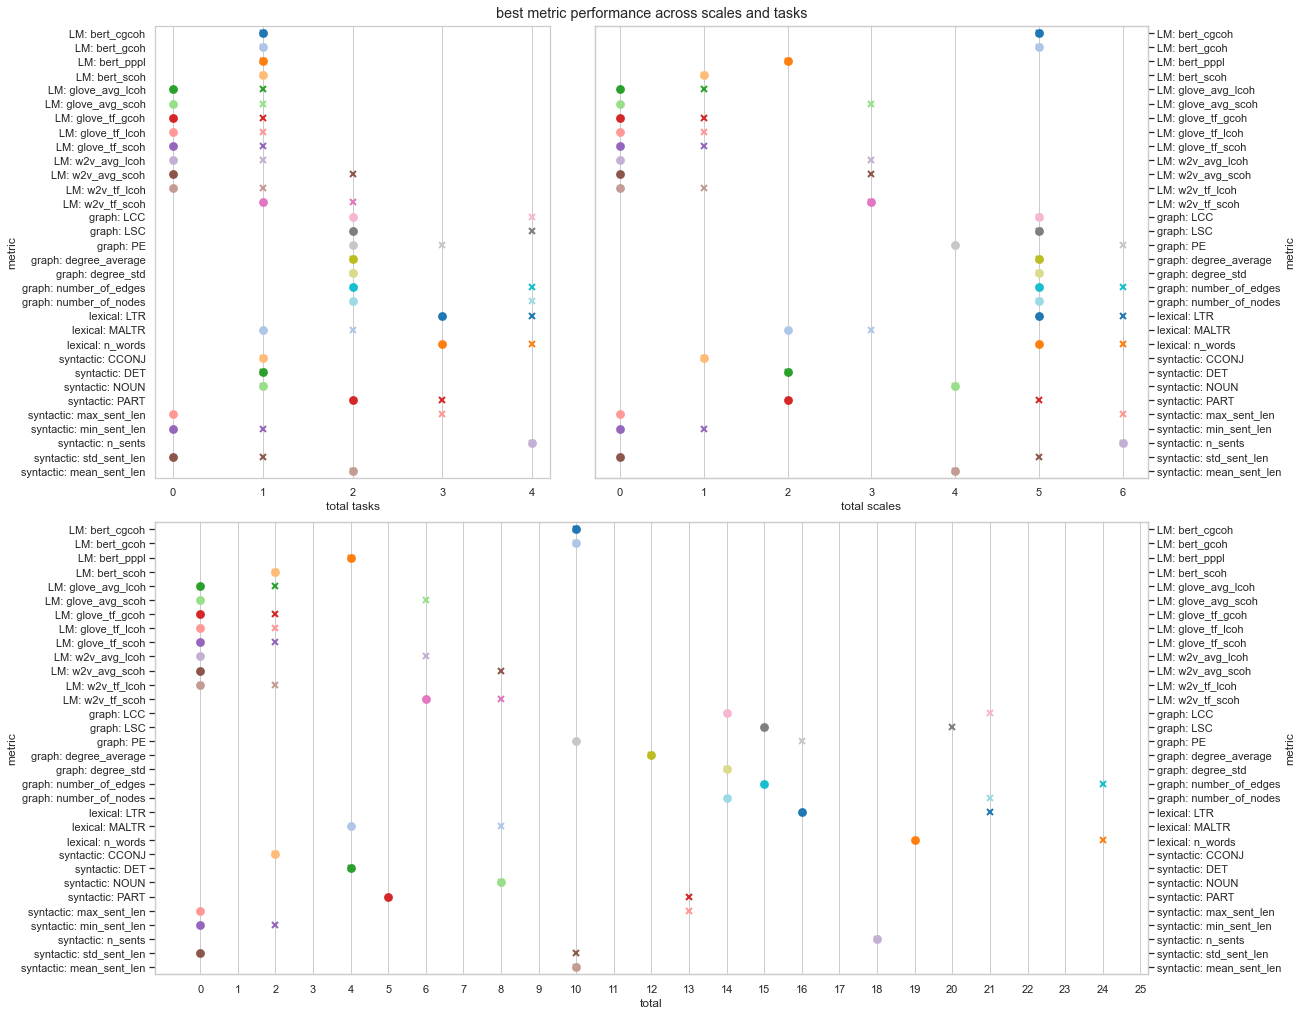

In [103]:
fig, axd = plt.subplot_mosaic([['left', 'right'], ['bottom', 'bottom']],
                              constrained_layout=True, figsize=(18, 14),
                              width_ratios=[5 / 12, 7 / 12])
plt.suptitle('best metric performance across scales and tasks')

axd['left'].set_xticks(np.arange(5))
axd['left'].set_xlabel('total tasks')
d = metric_by_task(idxs_task_scale, idxs)
d_l = metric_by_task_w_corr_len(idxs_task_scale, idxs_bb_task_scale, idxs, idxs_bb_task)
for i in d_l.index:
    if i not in d.index:
        d.loc[i, 'total_tasks'] = 0

d['metric'] = [': '.join(x) for x in d.index]
d_l['metric'] = [': '.join(x) for x in d_l.index]
pointplot_horizontal_wo_errorbar(d, x='total_tasks', ax=axd['left'], markers='o')
pointplot_horizontal_wo_errorbar(d_l, x='total_tasks', ax=axd['left'], markers='x')

axd['right'].set_xticks(np.arange(7))
axd['right'].set_yticks([])
axd['right'].set_xlabel('total scales')
d = metric_by_scale(idxs_scale, idxs_task_scale)
d_l = metric_by_scale_w_corr_len(idxs_scale, idxs_bb_scale, idxs_task_scale, idxs_bb_task_scale)
for i in d_l.index:
    if i not in d.index:
        d.loc[i, 'total_scales'] = 0
        d.loc[i, 'total'] = 0
d['metric'] = [': '.join(x) for x in d.index]
d_l['metric'] = [': '.join(x) for x in d_l.index]
ax2 = axd['right'].twinx()
pointplot_horizontal_wo_errorbar(d, x='total_scales', ax=ax2, markers='o')
pointplot_horizontal_wo_errorbar(d_l, x='total_scales', ax=ax2, markers='x')

axd['bottom'].set_xticks(np.arange(26))
pointplot_horizontal_wo_errorbar(d, x='total', ax=axd['bottom'], markers='o')
ax3 = axd['bottom'].twinx()
pointplot_horizontal_wo_errorbar(d_l, x='total', ax=ax3, markers='x')
plt.savefig(f'{PATH_FIG}/cross_task_compare_performance.png', dpi=150, bbox_inches='tight')

In [104]:
for i in d.index.levels[0]:
    print(i)
    for j in d.loc[i].index:
        print('\t', j)

LM
	 bert_cgcoh
	 bert_gcoh
	 bert_pppl
	 bert_scoh
	 w2v_tf_scoh
	 glove_avg_lcoh
	 glove_avg_scoh
	 glove_tf_gcoh
	 glove_tf_lcoh
	 glove_tf_scoh
	 w2v_avg_lcoh
	 w2v_avg_scoh
	 w2v_tf_lcoh
graph
	 LCC
	 LSC
	 PE
	 degree_average
	 degree_std
	 number_of_edges
	 number_of_nodes
lexical
	 LTR
	 MALTR
	 n_words
syntactic
	 CCONJ
	 DET
	 NOUN
	 PART
	 mean_sent_len
	 n_sents
	 max_sent_len
	 min_sent_len
	 std_sent_len


## Images for cross-metric comparison

In [105]:
def sort_index(idxs):
    ms = sorted(idxs)
    for s in ('syntactic: mean_sent_len', 'mean_sent_len', ('syntactic', 'mean_sent_len')):
        if s in ms:
            ms.remove(s)
            ms.append(s)
    return ms

In [106]:
abs_med_df = median_bootstrap.applymap(abs)

In [107]:
panss_idx = [(task, scale, 'r') for task in TASKS for scale in panss_]
ord_idx = [(task, 'panss_total', scale) for task in TASKS for scale in ('ps_r_dep.severity', 'ps_r_td.severity')]
corr_len_idx = [(task, 'panss_total', 'r_corr_w_control') for task in TASKS]

In [108]:
mean_abs_corr_len = abs_med_df[corr_len_idx].apply(np.nanmean, axis=1)

In [109]:
mean_across_tasks = pd.DataFrame(index=abs_med_df.index)
for scale in panss_:
    mean_across_tasks[(scale, 'r')] = median_bootstrap[panss_idx].apply(
        lambda row: [row[task][scale]['r'] for task in TASKS], axis=1)
for scale in ('ps_r_dep.severity', 'ps_r_td.severity'):
    mean_across_tasks[('panss_total', scale)] = median_bootstrap[ord_idx].apply(
        lambda row: [row[task]['panss_total'][scale] for task in TASKS], axis=1)
mean_across_tasks.columns = pd.MultiIndex.from_tuples(mean_across_tasks.columns)

In [110]:
def add_len_lines_no_task(ax, df, scale, add_neg=True):
    if scale not in ('ps_r_dep.severity', 'ps_r_td.severity'):
        median = np.median(df[scale].loc[('syntactic', 'mean_sent_len')]['r'])
    else:
        median = np.median(df['panss_total'].loc[('syntactic', 'mean_sent_len')][scale])
    ax.axvline(median, linestyle='--')
    if add_neg:
        ax.axvline(-median, linestyle='--')

In [111]:
def check_m(m, scale, scales_df, mean_abs_corr_len, r=0.3, rc=0.3):
    if scale not in ('ps_r_dep.severity', 'ps_r_td.severity'):
        median = np.median(scales_df[scale].loc[m]['r'])
    else:
        median = np.median(scales_df['panss_total'].loc[m][scale])
    ok_corr = mean_abs_corr_len.loc[m] < rc
    mr = abs(median)
    ok_scale = mr > r
    return ok_corr and ok_scale

In [112]:
def plot_subplot(ax, measure, scale, mean_across_tasks, mean_abs_corr_len, idxs, plot_abs=False, ax_share=None):
    if abs(np.nanmean(mean_across_tasks[scale].loc[('syntactic', 'mean_sent_len')]['r'])) > 0.3:
        add_len_lines_no_task(ax, mean_across_tasks, scale)
    markers = ['o' if check_m(m, scale, mean_across_tasks, mean_abs_corr_len) else 'x' for m in idxs]
    d = prep_horizontal_pointplot_errobar_data(mean_across_tasks[scale].loc[idxs], measure, plot_abs=plot_abs)
    pointplot_horizontal(d, x=measure, ax=ax, markers=markers, estimator='mean', errorbar="sd")
    ax.set_title(f'{measure} {scale}')
    if ax_share:
        ax.sharex(ax_share)

In [113]:
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
fig.suptitle(f'cross-scale cross-type metric comparison averaged across tasks', y=0.9)
plt.subplots_adjust(hspace=0.15)
plt.subplots_adjust(wspace=0.4)
ms = sorted(list(set([y for x in idxs_scale.values() for y in x] + [y for x in idxs_bb_scale.values() for y in x])))

idxs_ = sort_index(ms)

measure = 'r'
plot_abs = False

axs = axes.flatten()
for i, scale in enumerate(panss_order):
    ax = axs[i]
    plot_subplot(ax, measure, scale, mean_across_tasks, mean_abs_corr_len, idxs_)

add_grey(axes[:2, :])

scale = 'ps_r_td.severity'
ax = axes[2, 0]
if abs(np.nanmean(mean_across_tasks['panss_total'].loc[('syntactic', 'mean_sent_len')][scale])) > 0.09:
    add_len_lines_no_task(ax, mean_across_tasks, scale)
markers = ['o' if check_m(m, scale, mean_across_tasks, mean_abs_corr_len, r=0.09) else 'x' for m in idxs_]
d = prep_horizontal_pointplot_errobar_data(mean_across_tasks['panss_total'].loc[idxs_], 'ps_r_td.severity')
pointplot_horizontal(d, x='ps_r_td.severity', ax=ax, markers=markers, estimator='mean', errorbar="sd")
ax.set_xlabel('pseudo r squared')
ax.set_title(f'td severity')

scale = 'ps_r_dep.severity'
ax = axes[2, 1]
if abs(np.nanmean(mean_across_tasks['panss_total'].loc[('syntactic', 'mean_sent_len')][scale])) > 0.09:
    add_len_lines_no_task(ax, mean_across_tasks, scale)
markers = ['o' if check_m(m, scale, mean_across_tasks, mean_abs_corr_len, r=0.09) else 'x' for m in idxs_]
d = prep_horizontal_pointplot_errobar_data(mean_across_tasks['panss_total'].loc[idxs_], 'ps_r_dep.severity')
pointplot_horizontal(d, x='ps_r_dep.severity', ax=ax, markers=markers, estimator='mean', errorbar="sd")
ax.set_xlabel('pseudo r squared')
ax.set_title(f'dep severity')
ax.sharex(axes[2, 0])
add_grey(axes[2, :], r=0.09)

plt.savefig(f'{PATH_FIG}/cross_task_average_compare_r.png', dpi=150, bbox_inches='tight')
plt.close(fig)

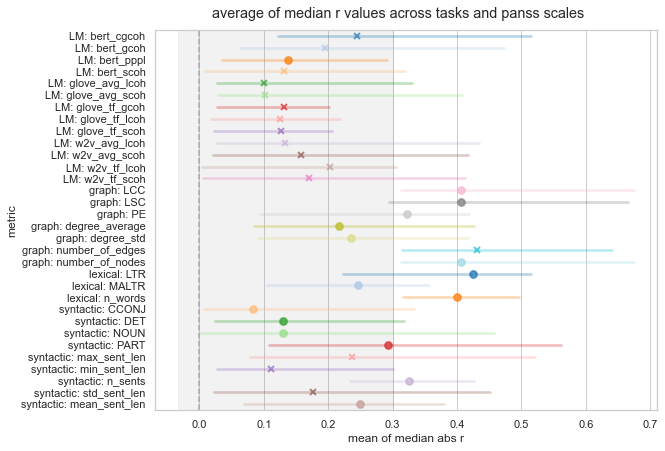

In [114]:
ms = sorted(list(set([y for x in idxs_scale.values() for y in x] + [y for x in idxs_bb_scale.values() for y in x])))
markers = ['o' if pd.isna(mean_abs_corr_len[m]) or mean_abs_corr_len[m] <= 0.3 else 'x' for m in sort_index(ms)]
median_asb_r = pd.DataFrame(abs_med_df.loc[ms][panss_idx].apply(lambda x: x.to_list(), axis=1),
                            columns=['mean of median abs r'])

d = prep_horizontal_pointplot_errobar_data(median_asb_r, 'mean of median abs r')
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
pointplot_horizontal(d, 'mean of median abs r', ax, markers=markers, errorbar=ERRORBAR)
add_grey(ax)
fig.suptitle('average of median r values across tasks and panss scales', y=0.925);
plt.savefig(f'{PATH_FIG}/cross_task_compare_r.png', dpi=150, bbox_inches='tight')

In [115]:
len(ms)

32

In [116]:
len(set([y for x in idxs_scale.values() for y in x]))

21

### For each scale

In [117]:
def add_control_lines(ax, df, task, scale, control_col=('syntactic', 'mean_sent_len'), add_neg=True):
    if scale not in ('ps_r_dep.severity', 'ps_r_td.severity'):
        median = np.median(df[task][scale].loc[control_col]['r'])
    else:
        median = np.median(df[task]['panss_total'].loc[control_col][scale])
    ax.axvline(median, linestyle='--')
    if add_neg:
        ax.axvline(-median, linestyle='--')

In [118]:
def add_len_lines(ax, df, task, scale, add_neg=True):
    if scale not in ('ps_r_dep.severity', 'ps_r_td.severity'):
        median = np.median(df[task][scale].loc[('syntactic', 'mean_sent_len')]['r'])
    else:
        median = np.median(df[task]['panss_total'].loc[('syntactic', 'mean_sent_len')][scale])
    ax.axvline(median, linestyle='--')
    if add_neg:
        ax.axvline(-median, linestyle='--')

In [119]:
def plot_one_scale_for_all_tasks_across_best_metrics(df, idxs, idxs_task_scale, scale,
                                                     measure='r', plot_abs=False, r=0.3, title=None,
                                                     xname=None, figsize=(18, 6),
                                                     add_neg=True, errorbar=ERRORBAR):
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    tit_scale = scale if measure == 'r' else measure
    if title is None:
        title = f'cross-task cross-type metric comparison for {tit_scale}'
    fig.suptitle(title, y=0.95)
    plt.subplots_adjust(wspace=0.4,
                        hspace=0.1)  #left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

    idxs = sort_index(idxs)

    axs = axes.flatten()
    for i, task in enumerate(TASKS):
        ax = axs[i]
        if ('syntactic', 'mean_sent_len') in idxs_task_scale[task][tit_scale]:
            add_len_lines(ax, df, task, tit_scale, add_neg=add_neg)
        markers = ['o' if m in idxs_task_scale[task][tit_scale] else 'x' for m in idxs]
        d = prep_horizontal_pointplot_errobar_data(df[task][scale].loc[idxs], measure, plot_abs=plot_abs)
        pointplot_horizontal(d, x=measure, ax=ax, markers=markers, errorbar=errorbar)
        ax.set_title(task)
    add_grey(axes, r=r)

    if xname is None:
        xname = measure

    for ax in axes.reshape(-1):
        label = 'abs ' + xname if plot_abs else xname
        ax.set_xlabel(label)

    return fig
    # plt.savefig(f'{PATH_FIG}/compare_r.png', dpi=150, bbox_inches = 'tight')

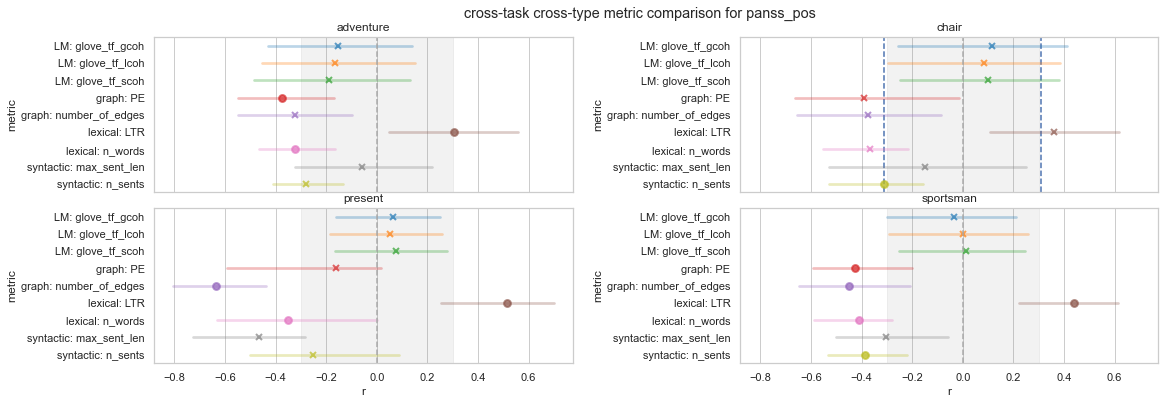

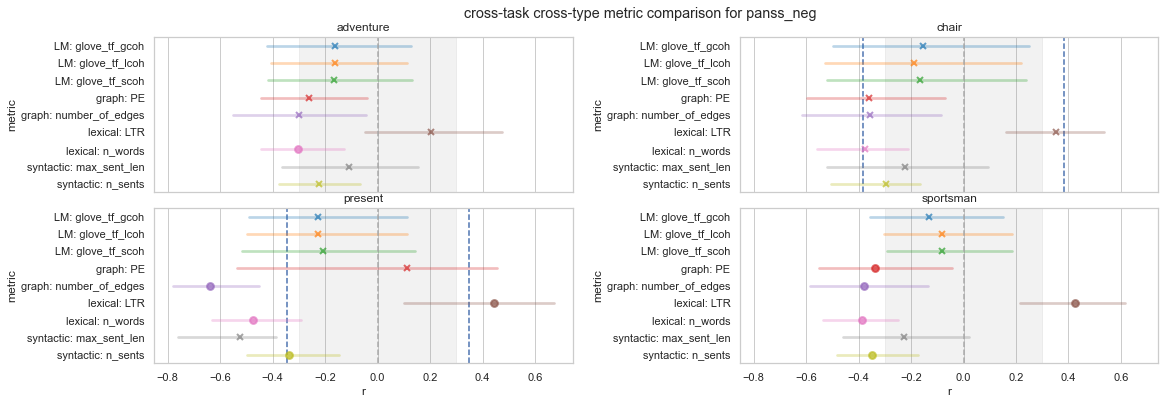

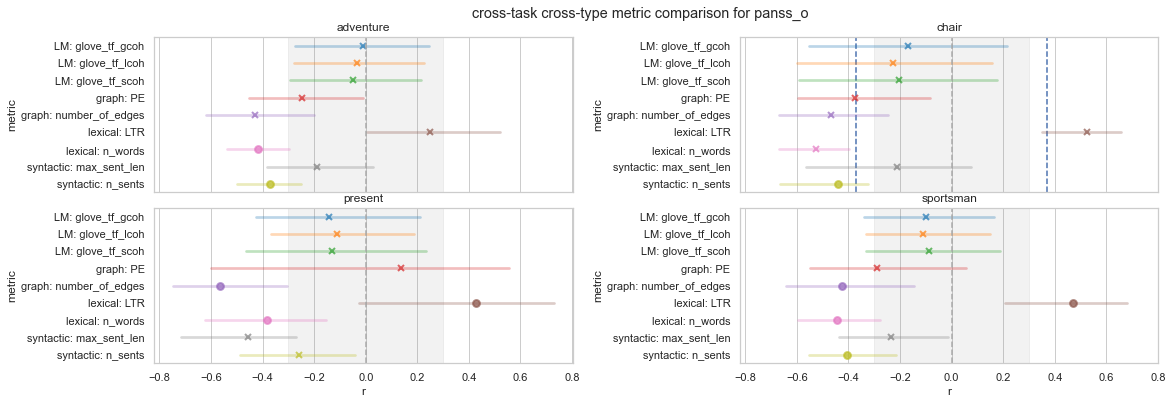

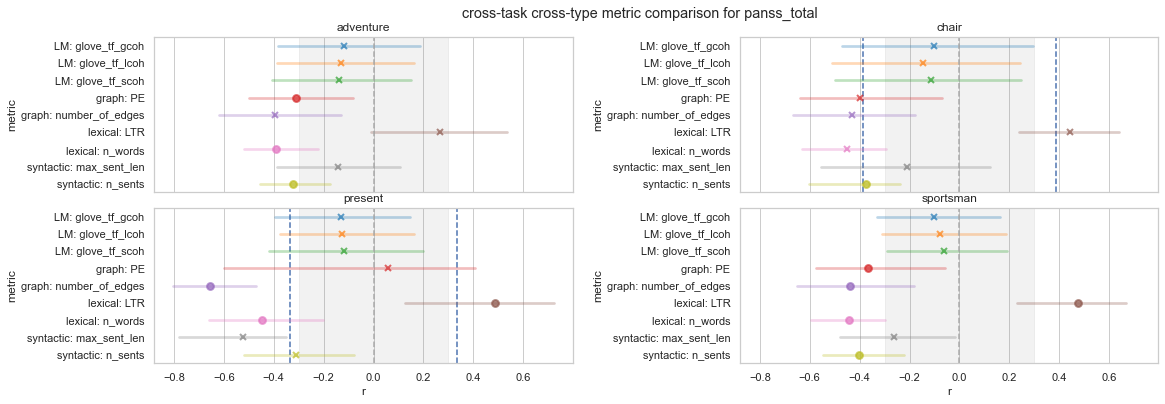

In [120]:
for p_scale in panss_:
    fig = plot_one_scale_for_all_tasks_across_best_metrics(reformed_d,
                                                           set(idxs_scale[scale] + idxs_bb_scale[scale]),
                                                           idxs_task_scale, scale=p_scale, errorbar=ERRORBAR)
#     plt.savefig(f'{PATH_FIG}/compare_{p_scale}.png', dpi=150, bbox_inches = 'tight')
#     plt.close(fig)

In [121]:
fig = plot_one_scale_for_all_tasks_across_best_metrics(reformed_d,
                                                       set(idxs_scale['ps_r_dep.severity']
                                                           + idxs_bb_scale['ps_r_dep.severity']),
                                                       idxs_task_scale,
                                                       scale='panss_pos', measure='ps_r_dep.severity', r=0.09,
                                                       title='cross-task cross-type metric comparison for dep severity',
                                                       xname='pseudo r squared', add_neg=False, errorbar=ERRORBAR)
plt.savefig(f'{PATH_FIG}/compare_dep_severity.png', dpi=150, bbox_inches='tight')
plt.close(fig)

In [122]:
fig = plot_one_scale_for_all_tasks_across_best_metrics(reformed_d,
                                                       set(idxs_scale['ps_r_td.severity']
                                                           + idxs_bb_scale['ps_r_td.severity']),
                                                       idxs_task_scale, scale='panss_pos',
                                                       measure='ps_r_td.severity', r=0.09,
                                                       title='cross-task cross-type metric comparison for td severity',
                                                       xname='pseudo r squared', add_neg=False, errorbar=ERRORBAR)
plt.savefig(f'{PATH_FIG}/compare_td_severity.png', dpi=150, bbox_inches='tight')
plt.close(fig)

In [123]:
# fig = plot_one_scale_for_all_tasks_across_best_metrics(reformed_d, bad_ms,
#                                                        {t: {'r_corr_w_control': idxs_corr_len[t]} for t in
#                                                         idxs_corr_len},
#                                                        scale='panss_pos', measure='r_corr_w_control',
#                                                        title='cross-task cross-type metric comparison for correlation with mean sent len',
#                                                        xname='r', figsize=(20, 20), errorbar=ERRORBAR)
# plt.savefig(f'{PATH_FIG}/compare_corr_len.png', dpi=150, bbox_inches='tight')
# plt.close(fig)

### best across tasks

In [124]:
def plot_all_scales_for_task_across_best_metrics(df, idxs, idxs_task_scale, task,
                                                 measure='r', plot_abs=False, figsize=(18, 8), use_markers=True, errorbar=ERRORBAR):
    absolute_value = f' (absolute r value)' if plot_abs else ''
    ab = 'abs ' if plot_abs else ''
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(f'cross-scale cross-type metric comparison {absolute_value} for {task} task', y=0.925)
    plt.subplots_adjust(wspace=0.4, hspace=0.3)

    idxs = sort_index(idxs)

    scale = 'panss_pos'
    if ('syntactic', 'mean_sent_len') in idxs_task_scale[task][scale]:
        add_len_lines(axes[0, 0], df, task, scale)
    markers = ['o' if m in idxs_task_scale[task][scale] else 'x' for m in idxs]
    d = prep_horizontal_pointplot_errobar_data(df[task][scale].loc[idxs], measure, plot_abs=plot_abs)
    pointplot_horizontal(d, x=measure, ax=axes[0, 0], markers=markers if use_markers else 'o', errorbar=errorbar)
    axes[0, 0].set_title(f'{ab}{measure} {scale}')

    scale = 'panss_neg'
    if ('syntactic', 'mean_sent_len') in idxs_task_scale[task][scale]:
        add_len_lines(axes[0, 1], df, task, scale)
    markers = ['o' if m in idxs_task_scale[task][scale] else 'x' for m in idxs]
    d = prep_horizontal_pointplot_errobar_data(df[task][scale].loc[idxs], measure, plot_abs=plot_abs)
    pointplot_horizontal(d, x=measure, ax=axes[0, 1], markers=markers if use_markers else 'o', errorbar=errorbar)
    axes[0, 1].set_title(f'{ab}{measure} {scale}')
    axes[0, 1].sharex(axes[0, 0])

    scale = 'panss_o'
    if ('syntactic', 'mean_sent_len') in idxs_task_scale[task][scale]:
        add_len_lines(axes[1, 0], df, task, scale)
    markers = ['o' if m in idxs_task_scale[task][scale] else 'x' for m in idxs]
    d = prep_horizontal_pointplot_errobar_data(df[task][scale].loc[idxs], measure, plot_abs=plot_abs)
    pointplot_horizontal(d, x=measure, ax=axes[1, 0], markers=markers if use_markers else 'o', errorbar=errorbar)
    axes[1, 0].set_title(f'{ab}{measure} {scale}')
    axes[1, 0].sharex(axes[0, 0])

    scale = 'panss_total'
    if ('syntactic', 'mean_sent_len') in idxs_task_scale[task][scale]:
        add_len_lines(axes[1, 1], df, task, scale)
    markers = ['o' if m in idxs_task_scale[task][scale] else 'x' for m in idxs]
    d = prep_horizontal_pointplot_errobar_data(df[task][scale].loc[idxs], measure, plot_abs=plot_abs)
    pointplot_horizontal(d, x=measure, ax=axes[1, 1], markers=markers if use_markers else 'o', errorbar=errorbar)
    axes[1, 1].set_title(f'{ab}{measure} {scale}')
    axes[1, 1].sharex(axes[0, 0])
    add_grey(axes[:2, :])

    if plot_abs:
        for ax in axes[:2, :].reshape(-1):
            ax.set_xlabel('abs ' + measure);

    scale = 'ps_r_td.severity'
    if ('syntactic', 'mean_sent_len') in idxs_task_scale[task][scale]:
        add_len_lines(axes[2, 0], df, task, scale, add_neg=False)
    markers = ['o' if m in idxs_task_scale[task][scale] else 'x' for m in idxs]
    d = prep_horizontal_pointplot_errobar_data(df[task]['panss_total'].loc[idxs], 'ps_r_td.severity')
    pointplot_horizontal(d, x='ps_r_td.severity', ax=axes[2, 0], markers=markers if use_markers else 'o', errorbar=errorbar)
    axes[2, 0].set_xlabel('pseudo r squared');
    axes[2, 0].set_title(f'td severity')

    scale = 'ps_r_dep.severity'
    if ('syntactic', 'mean_sent_len') in idxs_task_scale[task][scale]:
        add_len_lines(axes[2, 1], df, task, scale, add_neg=False)
    markers = ['o' if m in idxs_task_scale[task][scale] else 'x' for m in idxs]
    d = prep_horizontal_pointplot_errobar_data(df[task]['panss_total'].loc[idxs], 'ps_r_dep.severity')
    pointplot_horizontal(d, x='ps_r_dep.severity', ax=axes[2, 1], markers=markers if use_markers else 'o', errorbar=errorbar)
    axes[2, 1].set_xlabel('pseudo r squared');
    axes[2, 1].set_title(f'dep severity')
    axes[2, 1].sharex(axes[2, 0])
    add_grey(axes[2, :], r=0.09)

    return fig

In [125]:
figsizes = {
    'adventure': (18, 8),
    'chair': (18, 13),
    'present': (18, 15),
    'sportsman': (18, 10),
}
for task in TASKS:
    fig = plot_all_scales_for_task_across_best_metrics(reformed_d,
                                                       set(idxs[task]).union(idxs_bb_task[task]),
                                                       idxs_task_scale, task, figsize=figsizes[task], 
                                                       errorbar=ERRORBAR)
    plt.savefig(f'{PATH_FIG}/compare_{task}.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

### T-test

In [126]:
def select_ok_metrics_t(row, low=0.25, high=0.75):
    q_low = np.quantile(row['panss_total', 't'], low)
    q_high = np.quantile(row['panss_total', 't'], high)
    return q_low > 0 or q_high < 0

In [127]:
reformed_d['chair'][reformed_d['chair'].apply(select_ok_metrics_t, axis=1)].index

MultiIndex([(       'LM',       'bert_lcoh'),
            (       'LM',       'bert_pppl'),
            (       'LM',       'bert_scoh'),
            (       'LM',      'bert_sprob'),
            (       'LM',  'glove_avg_gcoh'),
            (       'LM',  'glove_avg_lcoh'),
            (       'LM',  'glove_avg_scoh'),
            (       'LM',  'glove_tf_cgcoh'),
            (       'LM',   'glove_tf_gcoh'),
            (       'LM',   'glove_tf_lcoh'),
            (       'LM',   'glove_tf_scoh'),
            (       'LM',   'w2v_avg_cgcoh'),
            (       'LM',    'w2v_avg_lcoh'),
            (       'LM',    'w2v_avg_scoh'),
            (       'LM',    'w2v_tf_cgcoh'),
            (       'LM',     'w2v_tf_gcoh'),
            (    'graph',              'L1'),
            (    'graph',              'L2'),
            (    'graph',              'L3'),
            (    'graph',             'LCC'),
            (    'graph',             'LSC'),
            (    'graph',         

In [128]:
reformed_d['adventure'][reformed_d['adventure'].apply(select_ok_metrics_t, axis=1)].index

MultiIndex([(       'LM',      'bert_cgcoh'),
            (       'LM',       'bert_gcoh'),
            (       'LM',       'bert_pppl'),
            (       'LM', 'glove_avg_cgcoh'),
            (       'LM',   'w2v_avg_cgcoh'),
            (       'LM',    'w2v_avg_scoh'),
            (       'LM',    'w2v_tf_cgcoh'),
            (       'LM',     'w2v_tf_scoh'),
            (    'graph',              'L1'),
            (    'graph',              'L2'),
            (    'graph',              'L3'),
            (    'graph',             'LCC'),
            (    'graph',             'LSC'),
            (    'graph',              'PE'),
            (    'graph', 'number_of_edges'),
            (    'graph', 'number_of_nodes'),
            (  'lexical',             'LTR'),
            (  'lexical',           'MALTR'),
            (  'lexical',         'n_words'),
            ('syntactic',             'ADJ'),
            ('syntactic',             'ADV'),
            ('syntactic',         

In [129]:
reformed_d['sportsman'][reformed_d['sportsman'].apply(select_ok_metrics_t, axis=1)].index

MultiIndex([(       'LM',      'bert_cgcoh'),
            (       'LM',       'bert_gcoh'),
            (       'LM',       'bert_lcoh'),
            (       'LM',       'bert_pppl'),
            (       'LM',       'bert_scoh'),
            (       'LM',      'bert_sprob'),
            (       'LM',  'glove_avg_scoh'),
            (       'LM',   'w2v_avg_cgcoh'),
            (       'LM',    'w2v_avg_lcoh'),
            (       'LM',    'w2v_tf_cgcoh'),
            (       'LM',     'w2v_tf_lcoh'),
            (    'graph',              'L1'),
            (    'graph',             'LCC'),
            (    'graph',             'LSC'),
            (    'graph',              'PE'),
            (    'graph',  'degree_average'),
            (    'graph',      'degree_std'),
            (    'graph', 'number_of_edges'),
            (    'graph', 'number_of_nodes'),
            (  'lexical',             'LTR'),
            (  'lexical',           'MALTR'),
            (  'lexical',         

In [130]:
reformed_d['present'][reformed_d['present'].apply(select_ok_metrics_t, axis=1)].index

MultiIndex([(       'LM',      'bert_cgcoh'),
            (       'LM',       'bert_gcoh'),
            (       'LM',       'bert_lcoh'),
            (       'LM',       'bert_pppl'),
            (       'LM',       'bert_scoh'),
            (       'LM', 'glove_avg_cgcoh'),
            (       'LM',  'glove_avg_gcoh'),
            (       'LM',  'glove_avg_lcoh'),
            (       'LM',  'glove_avg_scoh'),
            (       'LM',  'glove_tf_cgcoh'),
            (       'LM',   'glove_tf_gcoh'),
            (       'LM',   'glove_tf_lcoh'),
            (       'LM',   'glove_tf_scoh'),
            (       'LM',    'w2v_avg_gcoh'),
            (       'LM',    'w2v_avg_lcoh'),
            (       'LM',    'w2v_avg_scoh'),
            (       'LM',     'w2v_tf_gcoh'),
            (       'LM',     'w2v_tf_lcoh'),
            (       'LM',     'w2v_tf_scoh'),
            (    'graph',              'L1'),
            (    'graph',              'L2'),
            (    'graph',         

### average LM model / metric performance medians across scales

In [131]:
def mean_model_metric_medians(median_df, tsk, leave_out=()):
    resp_d_model = pd.DataFrame(columns=[f'{sc} abs r' for sc in panss_] + list(sc_ind_), index=models_)
    resp_d_metric = pd.DataFrame(columns=[f'{sc} abs r' for sc in panss_] + list(sc_ind_), index=metrics_)
    for scale in panss_:
        ex_d = prep_LM_pointplot(median_df.loc['LM', (tsk, scale)], col='r', use_errorbar=False, plot_abs=True)
        if leave_out:
            leave_out_ = ex_d.drop(ex_d[ex_d['metric'].isin(leave_out)].index)
        for model in models_:
            if leave_out:
                resp_d_model.loc[model, f'{scale} abs r'] = np.nanmean(leave_out_[leave_out_['model'] == model]['r'])
            else:
                resp_d_model.loc[model, f'{scale} abs r'] = np.nanmean(ex_d[ex_d['model'] == model]['r'])
        for metric in metrics_:
            resp_d_metric.loc[metric, f'{scale} abs r'] = np.nanmean(ex_d[ex_d['metric'] == metric]['r'])
    for sc_ind in sc_ind_:
        if leave_out:
            leave_out_ = ex_d.drop(ex_d[ex_d['metric'].isin(leave_out)].index)
        for model in models_:
            if leave_out:
                resp_d_model.loc[model, sc_ind] = np.nanmean(leave_out_[leave_out_['model'] == model][sc_ind])
            else:
                resp_d_model.loc[model, sc_ind] = np.nanmean(ex_d[ex_d['model'] == model][sc_ind])
        for metric in metrics_:
            resp_d_metric.loc[metric, sc_ind] = np.nanmean(ex_d[ex_d['metric'] == metric][sc_ind])
    return resp_d_model, resp_d_metric

#### only including cosine-similarity based metrics

In [132]:
dfs_model = []
dfs_metric = []

for task in TASKS:
    resp_d_model, resp_d_metric = mean_model_metric_medians(median_bootstrap, task, leave_out=('sprob', 'pppl'))
    dfs_model.append(resp_d_model)
    dfs_metric.append(resp_d_metric)

df_model = pd.concat(dfs_model, keys=TASKS, names=['task'], axis=1)
df_metric = pd.concat(dfs_metric, keys=TASKS, names=['task'], axis=1)

In [133]:
df_model['sportsman']

,panss_pos abs r,panss_neg abs r,panss_o abs r,panss_total abs r,t,r_corr_w_control,ps_r_dep.severity,ps_r_td.severity
bert,0.162187,0.15651,0.169223,0.173754,0.513164,0.373948,0.016427,0.020755
glove_tf,0.018632,0.104372,0.088828,0.087441,0.041688,0.500101,0.016616,0.012458
glove_avg,0.106723,0.040614,0.050345,0.042436,0.054562,0.628015,0.023785,0.015005
w2v_tf,0.096123,0.10897,0.096841,0.098505,0.184227,0.71108,0.031798,0.013529
w2v_avg,0.090773,0.077277,0.090087,0.080255,0.137622,0.744135,0.022216,0.019192


In [134]:
df_corr_len = pd.DataFrame()
for task in TASKS:
    df_corr_len[task] = df_model[task]['r_corr_w_control']
df_corr_len['mean'] = df_corr_len.apply(np.nanmean, axis=1)
df_corr_len

,adventure,chair,present,sportsman,mean
bert,0.337579,0.48851,0.253576,0.373948,0.363403
glove_tf,0.388105,0.392268,0.263819,0.500101,0.386073
glove_avg,0.368215,0.189773,0.442847,0.628015,0.407212
w2v_tf,0.465053,0.452374,0.381337,0.71108,0.502461
w2v_avg,0.593667,0.569552,0.531674,0.744135,0.609757


In [135]:
df_corr_len['mean'].sort_values()

bert         0.363403
glove_tf     0.386073
glove_avg    0.407212
w2v_tf       0.502461
w2v_avg      0.609757
Name: mean, dtype: float64

In [136]:
df_corr_sym = pd.DataFrame()
for task in TASKS:
    copy_ = df_model[task][['panss_pos abs r', 'panss_neg abs r', 'panss_o abs r', 'panss_total abs r']].copy()
    copy_['ps_r_dep.severity'] = df_model[task]['ps_r_dep.severity'] ** 0.5
    copy_['ps_r_td.severity'] = df_model[task]['ps_r_td.severity'] ** 0.5
    df_corr_sym[task] = copy_[['panss_pos abs r', 'panss_neg abs r', 'panss_o abs r', 'panss_total abs r',
                               'ps_r_dep.severity', 'ps_r_td.severity']].mean(axis=1)

df_corr_sym['mean'] = df_corr_sym.apply(np.nanmean, axis=1)
df_corr_sym

,adventure,chair,present,sportsman,mean
bert,0.109937,0.137969,0.317885,0.155651,0.180361
glove_tf,0.122171,0.167498,0.131017,0.089965,0.127663
glove_avg,0.085712,0.133443,0.202681,0.086139,0.126994
w2v_tf,0.166935,0.140056,0.195729,0.115845,0.154641
w2v_avg,0.148134,0.129196,0.211592,0.10433,0.148313


In [137]:
df_corr_sym['mean'].sort_values()

glove_avg    0.126994
glove_tf     0.127663
w2v_avg      0.148313
w2v_tf       0.154641
bert         0.180361
Name: mean, dtype: float64

In [138]:
df_metric['sportsman']

,panss_pos abs r,panss_neg abs r,panss_o abs r,panss_total abs r,t,r_corr_w_control,ps_r_dep.severity,ps_r_td.severity
cgcoh,0.183196,0.116198,0.119935,0.142023,0.346,0.568952,0.017241,0.024013
gcoh,0.074448,0.110492,0.082811,0.088487,0.144488,0.630541,0.019156,0.015445
lcoh,0.060411,0.102516,0.112975,0.100362,0.150293,0.559417,0.032537,0.01219
scoh,0.061496,0.060989,0.080538,0.05504,0.104229,0.606914,0.01974,0.013102
sprob,0.110585,0.20495,0.285809,0.226406,0.1209,0.153455,0.0255,0.025189
pppl,0.040897,0.097839,0.070937,0.031355,0.095336,0.076592,0.033634,0.032495


#### including feature based metrics for BERT

In [139]:
dfs_model = []
dfs_metric = []

for task in TASKS:
    resp_d_model, resp_d_metric = mean_model_metric_medians(median_bootstrap, task)
    dfs_model.append(resp_d_model)
    dfs_metric.append(resp_d_metric)

df_model = pd.concat(dfs_model, keys=TASKS, names=['task'], axis=1)
df_metric = pd.concat(dfs_metric, keys=TASKS, names=['task'], axis=1)

In [140]:
df_corr_sym = pd.DataFrame()
for task in TASKS:
    copy_ = df_model[task][['panss_pos abs r', 'panss_neg abs r', 'panss_o abs r', 'panss_total abs r']].copy()
    copy_['ps_r_dep.severity'] = df_model[task]['ps_r_dep.severity'] ** 0.5
    copy_['ps_r_td.severity'] = df_model[task]['ps_r_td.severity'] ** 0.5
    df_corr_sym[task] = copy_[['panss_pos abs r', 'panss_neg abs r', 'panss_o abs r', 'panss_total abs r',
                               'ps_r_dep.severity', 'ps_r_td.severity']].mean(axis=1)

df_corr_sym['mean'] = df_corr_sym.apply(np.nanmean, axis=1)
df_corr_sym

,adventure,chair,present,sportsman,mean
bert,0.123741,0.133444,0.268742,0.152771,0.169675
glove_tf,0.122171,0.167498,0.131017,0.089965,0.127663
glove_avg,0.085712,0.133443,0.202681,0.086139,0.126994
w2v_tf,0.166935,0.140056,0.195729,0.115845,0.154641
w2v_avg,0.148134,0.129196,0.211592,0.10433,0.148313


In [141]:
df_corr_len = pd.DataFrame()
for task in TASKS:
    df_corr_len[task] = df_model[task]['r_corr_w_control']
df_corr_len['mean'] = df_corr_len.apply(np.nanmean, axis=1)
df_corr_len

,adventure,chair,present,sportsman,mean
bert,0.264342,0.340279,0.184482,0.28764,0.269186
glove_tf,0.388105,0.392268,0.263819,0.500101,0.386073
glove_avg,0.368215,0.189773,0.442847,0.628015,0.407212
w2v_tf,0.465053,0.452374,0.381337,0.71108,0.502461
w2v_avg,0.593667,0.569552,0.531674,0.744135,0.609757


In [142]:
df_corr_len['mean'].sort_values()

bert         0.269186
glove_tf     0.386073
glove_avg    0.407212
w2v_tf       0.502461
w2v_avg      0.609757
Name: mean, dtype: float64

# Reform the dataset to long format

index: unique

langugae: de / ru

task: (de tasks) / (ru tasks) - 4 for each

scale: (de: panss sans saps t test) / (ru: panss dep td t test)

metric: name

matric_group: 4

values: median CI_low CI_high corr_mean_sent_len corr_n_sent corr_n_word

In [143]:
control_corr_names = ['r_corr_w_mean_sent_len', 'r_corr_w_n_sents', 'r_corr_w_n_words']

In [144]:
low = 0.025
high = 0.975
lang = 'ru'

In [145]:
reformed_d = pd.DataFrame(reform)

In [147]:
ordered_computed = False
ordered = ['ps_r_dep.severity', 'ps_r_td.severity'] if ordered_computed else []
additional_analysis_metrics_computed = True
additional_analysis_metrics = ['auc'] if additional_analysis_metrics_computed else []


In [148]:
group_diff_metrics = ['t', 'auc', 'llh_lr_bv_m', 'llh_lr_diff', 'llh_lr_marginal_diff', 
                     ]

In [149]:
group_diff_suffix = {'': ('sz', 'control_psy'),
                '_sz_dep' : ('sz', 'dep'),
                '_dep': ('dep', 'control_psy')}

In [150]:
reg_metrics_grouped = ['r']

reg_metrics_add_to_all = ['r_corr_w_mean_sent_len', 'r_corr_w_n_sents', 'r_corr_w_n_words']

reg_metrics_sz_only = ['r_ols_bv_m', 'r_ols_diff', 'r_ols_marginal'] # write that it is sz only in the long data

In [151]:
col_independent_metrics = ['r_ols_multi', 'r_ols_bv', 'r_ols_dc', 
                           'llh_lr_multi', 'llh_lr_bv', 'llh_lr_dc',
                          ]
# write that it is sz only in the long data

In [152]:
sfxs = {'': 'all', '_sz': 'psychosis_only', '_dep': 'depression_only'}

In [156]:
def process_data(reformed_d, data, control_corr_names_):
    median = np.nanmedian(data)
    mean = np.nanmean(data)
    CI_low = np.nanquantile(np.array(data), low)
    CI_high = np.nanquantile(np.array(data), high)
    control_cols_medians, control_cols_means, control_cols_CI_lows, control_cols_CI_highs = {}, {}, {}, {}
    for control_col in control_corr_names_:
        control_data = reformed_d[(task, scale_key, control_col)][metric]
        if len(control_data) == 0:
            c_median, c_mean, c_CI_high, c_CI_low = np.nan, np.nan, np.nan, np.nan
        else:
            c_median = np.nanmedian(control_data)
            c_mean = np.nanmean(control_data)
            c_CI_low = np.nanquantile(np.array(control_data), low)
            c_CI_high = np.nanquantile(np.array(control_data), high)

        control_cols_medians[control_col] = c_median
        control_cols_means[control_col] = c_mean
        control_cols_CI_lows[control_col] = c_CI_low
        control_cols_CI_highs[control_col] = c_CI_high
    return median, mean, CI_low, CI_high, control_cols_medians, control_cols_means, control_cols_CI_lows, control_cols_CI_highs

In [157]:
def get_performance_metric_to_write(scale_, performance_metric):
    if scale_.startswith('group_diff'):
        performance_metric_to_write = performance_metric.strip('_dep').strip('_sz')
    elif scale_.startswith('ps_r'):
        performance_metric_to_write = 'ps_r'
    else:
        performance_metric_to_write = performance_metric.strip('_dep').strip('_sz')
    return performance_metric_to_write

In [158]:
def get_group_pair(scale_, performance_metric_key):
    # multi: llh logistic multi, llh best verbosity, llh default covariates
    if scale_ == 'multivariate' and performance_metric_key.startswith("llh"):
        group_pair = "control_sz"
    # group_diff: t, auc, llh logistic, llh logistic diff
    elif 'group_diff' in scale_:
        if "_sz_dep" in performance_metric_key:
            group_pair = "sz_dep"
        elif "_dep" in performance_metric_key:
            group_pair = "control_dep"
        else:
            group_pair = "control_sz"
    else:
        group_pair = np.nan
    return group_pair

In [159]:
def form_long_line(reformed_d, metric, task, scale_, scale_key, performance_metric_, performance_metric_key, group, predictor_varset, control_corr_names_):
    metric_group, metric_name = metric
    data = reformed_d[(task, scale_key, performance_metric_key)][(metric_group, metric_name)]
    median, mean, CI_low, CI_high, control_cols_medians, control_cols_means, control_cols_CI_lows, control_cols_CI_highs = process_data(reformed_d, data, control_corr_names_)
    
    group_pair = get_group_pair(scale_, performance_metric_key)

    long_line = (lang, group, task, scale_, performance_metric_, predictor_varset,
                 metric_group, metric_name, group_pair, 
                 median, mean, CI_low, CI_high)

    for control_col in control_corr_names_:
        long_line += (control_cols_medians[control_col], control_cols_means[control_col],
                      control_cols_CI_lows[control_col], control_cols_CI_highs[control_col])
    return long_line

In [160]:
def update_long_data(long_data, reformed_d, metric, task, scale_, scale_key, performance_metric_, 
                     performance_metric_key, group, predictor_varset, control_corr_names_):
    long_line = form_long_line(reformed_d, metric, task, scale_, scale_key, performance_metric_, 
                               performance_metric_key, group, predictor_varset, control_corr_names_)
    if long_line not in long_data:
        long_data.append(long_line)
    else:
        print(long_line)

In [161]:
pm_varset_map = {
    "r": ("r", "single"),
    "r_sz": ("r", "single"),
    "r_dep": ("r", "single"),
    
    "t": ("t", "single"),
    "t_dep": ("t", "single"),
    "t_sz_dep": ("t", "single"),
    
    "ps_r_dep.severity": ("ps_r", "single"),
    "ps_r_td.severity": ("ps_r", "single"),
    
    "auc": ("auc", "single"),
    "auc_dep": ("auc", "single"),
    "auc_sz_dep": ("auc", "single"),
    
    "llh_lr_bv_m": ("llh", "dc_bv_m"),
    "llh_lr_bv_m_dep": ("llh", "dc_bv_m"),
    "llh_lr_bv_m_sz_dep": ("llh", "dc_bv_m"),
    
    "llh_lr_diff": ("llh_diff", "single"),
    "llh_lr_diff_dep": ("llh_diff", "single"),
    "llh_lr_diff_sz_dep": ("llh_diff", "single"),
    
    "llh_lr_marginal_diff": ("llh_marginal_diff", "single"),
    "llh_lr_marginal_diff_dep": ("llh_marginal_diff", "single"),
    "llh_lr_marginal_diff_sz_dep": ("llh_marginal_diff", "single"),
    
    "llh_lr_multi": ("llh", "multi"),
    "llh_lr_bv": ("llh", "dc_bv"),
    "llh_lr_dc": ("llh", "dc"),
    
    "r_ols_bv_m": ("r2", "dc_bv_m"),
    
    "r_ols_diff": ("r2_diff", "single"),
    
    "r_ols_marginal": ("r_marginal", "single"),
    
    "r_ols_multi": ("r2", "multi"),
    "r_ols_bv": ("r2", "dc_bv"),
    "r_ols_dc": ("r2", "dc"),
    
}

In [162]:
long_data = []
scales_ = panss_order + ['group_diff', 'group_diff_sz_dep', 'group_diff_dep'] + ordered
for task in TASKS:
    for sfx, group in sfxs.items():
        control_corr_names_ = [control_col + sfx for control_col in control_corr_names]
        # ___regressions___
        # r
        for scale_ in panss_order:
            scale_key = scale_
            performance_metric_key = "r" + sfx  # e.g. r_sz meaning sz only or r meaning all
            performance_metric_, predictor_varset = pm_varset_map[performance_metric_key]
            for metric in cols_tasks:
                update_long_data(long_data, reformed_d, metric, task, scale_, scale_key, 
                                 performance_metric_, performance_metric_key, 
                                 group, predictor_varset, control_corr_names_)
 
    
        # ordered
        if sfx != '_dep':
            # no ordered variables for depression available (the data is too homogeneous)
            for scale_ in ordered:
                scale_key = 'panss_total'
                performance_metric_key =  scale_ + sfx # e.g. ps_r_dep.severity_sz
                performance_metric_, predictor_varset = pm_varset_map[performance_metric_key]
                for metric in cols_tasks:
                    update_long_data(long_data, reformed_d, metric, task, scale_, scale_key, 
                                     performance_metric_, performance_metric_key, 
                                     group, predictor_varset, control_corr_names_)
    
        # OLS
        # r squared, r squared diff
        if sfx == '_sz':  # ols is calculated for sz group only
            # ['r_ols_bv_m', 'r_ols_diff', 'r_ols_marginal']
            for performance_metric_key in reg_metrics_sz_only:
                scale_key = 'panss_total'  # because target_col_corr=('target', 'panss_total')
                scale_ = 'panss_total'
                performance_metric_, predictor_varset = pm_varset_map[performance_metric_key]
                for metric in cols_tasks:
                    update_long_data(long_data, reformed_d, metric, task, scale_, scale_key, 
                                     performance_metric_, performance_metric_key, 
                                     group, predictor_varset, control_corr_names_)
                

        # ___group_diff___
        # t, auc, llh logistic, llh logistic diff, llh logistic marginal diff
        for pm in group_diff_metrics:
            for pair_suffix in group_diff_suffix:
                if pm == 'llh_ps_r_bv_m' and pair_suffix:
                    continue
                scale_ = 'group_diff' + pair_suffix     # group_diff_sz_dep or group_diff_dep          
                scale_key = 'panss_total'  
                performance_metric_key = pm + pair_suffix            # t llh_lr_diff
                performance_metric_, predictor_varset = pm_varset_map[performance_metric_key]
                for metric in cols_tasks:
                    update_long_data(long_data, reformed_d, metric, task, scale_, scale_key, 
                                     performance_metric_, performance_metric_key, 
                                     group, predictor_varset, control_corr_names_)


        # ___col independent___
        # OLS r squared multi
        # OLS best verbosity
        # OLS default covariates
        # llh logistic multi
        # llh best verbosity
        # llh default covariates
        if sfx == '_sz':
            metric = ('overview', 'col_independent')
            scale_key = 'panss_total'
            scale_ = 'multivariate'
            for performance_metric_key in col_independent_metrics:
                performance_metric_, predictor_varset = pm_varset_map[performance_metric_key]
                update_long_data(long_data, reformed_d, metric, task, scale_, scale_key, 
                                 performance_metric_, performance_metric_key, 
                                 group, predictor_varset, control_corr_names_)
       

In [163]:
long_df = pd.DataFrame(long_data, columns=('lang', 'subset', 'task', 'scale', 'performance_metric', 
                                           'predictor_varset', 'metric_group', 'metric_name', 'group_pair', 
                                           'median', 'mean', 'CI_low', 'CI_high',
                                           'corr_mean_sent_len_median', 'corr_mean_sent_len_mean',
                                           'corr_mean_sent_len_CI_low', 'corr_mean_sent_len_CI_high',
                                           'corr_n_sents_median', 'corr_n_sents_mean',
                                           'corr_n_sents_CI_low', 'corr_n_sents_CI_high',
                                           'corr_n_words_median', 'corr_n_words_mean',
                                           'corr_n_words_CI_low', 'corr_n_words_CI_high',))
long_df.head()

,lang,subset,task,scale,performance_metric,predictor_varset,metric_group,metric_name,group_pair,median,...,corr_mean_sent_len_CI_low,corr_mean_sent_len_CI_high,corr_n_sents_median,corr_n_sents_mean,corr_n_sents_CI_low,corr_n_sents_CI_high,corr_n_words_median,corr_n_words_mean,corr_n_words_CI_low,corr_n_words_CI_high
0,ru,all,adventure,panss_pos,r,single,LM,bert_cgcoh,NaN,0.185911,...,-0.505116,-0.047560,-0.065079,-0.066993,-0.224262,0.077879,-0.170771,-0.171971,-0.350994,0.005739
1,ru,all,adventure,panss_pos,r,single,LM,bert_gcoh,NaN,0.145932,...,-0.529105,-0.057349,-0.002128,-0.003239,-0.155031,0.142454,-0.105934,-0.105271,-0.277666,0.054232
2,ru,all,adventure,panss_pos,r,single,LM,bert_lcoh,NaN,0.060283,...,-0.650000,-0.187031,0.057554,0.053649,-0.097504,0.178627,-0.088019,-0.090089,-0.247464,0.048079
3,ru,all,adventure,panss_pos,r,single,LM,bert_pppl,NaN,-0.049748,...,-0.262785,0.046061,0.022020,0.028762,-0.100076,0.184479,-0.025813,-0.019954,-0.144806,0.150617
4,ru,all,adventure,panss_pos,r,single,LM,bert_scoh,NaN,0.031388,...,-0.496591,-0.047814,0.057205,0.058617,-0.115711,0.212662,-0.027037,-0.030616,-0.216807,0.144641


In [164]:
long_df.scale.unique()

array(['panss_pos', 'panss_neg', 'panss_o', 'panss_total', 'group_diff',
       'group_diff_sz_dep', 'group_diff_dep', 'multivariate'],
      dtype=object)

In [165]:
long_df.performance_metric.unique()

array(['r', 't', 'auc', 'llh', 'llh_diff', 'llh_marginal_diff', 'r2',
       'r2_diff', 'r_marginal'], dtype=object)

In [166]:
long_df.predictor_varset.unique()

array(['single', 'dc_bv_m', 'multi', 'dc_bv', 'dc'], dtype=object)

In [167]:
long_df.group_pair.unique()

array([nan, 'control_sz', 'sz_dep', 'control_dep'], dtype=object)

In [168]:
# correct T test order
long_df.loc[(long_df['performance_metric'] == 't') & (long_df['group_pair'] == 'control_sz'), ['mean', 'median', 'CI_high', 'CI_low']]  = -long_df.loc[(long_df['performance_metric'] == 't') & (long_df['group_pair'] == 'control_sz'), ['mean', 'median', 'CI_high', 'CI_low']]

In [169]:
# correct T test order
long_df.loc[(long_df['performance_metric'] == 't') & (long_df['group_pair'] == 'control_dep'), ['mean', 'median', 'CI_high', 'CI_low']]  = -long_df.loc[(long_df['performance_metric'] == 't') & (long_df['group_pair'] == 'control_dep'), ['mean', 'median', 'CI_high', 'CI_low']]

In [170]:
long_df[(long_df['lang'] == 'ru') & (long_df['task'] =='adventure') & (long_df['scale'] == 'group_diff') & (long_df['performance_metric'] =='t') & (long_df['metric_name'] =='bert_cgcoh')]

,lang,subset,task,scale,performance_metric,predictor_varset,metric_group,metric_name,group_pair,median,...,corr_mean_sent_len_CI_low,corr_mean_sent_len_CI_high,corr_n_sents_median,corr_n_sents_mean,corr_n_sents_CI_low,corr_n_sents_CI_high,corr_n_words_median,corr_n_words_mean,corr_n_words_CI_low,corr_n_words_CI_high
204,ru,all,adventure,group_diff,t,single,LM,bert_cgcoh,control_sz,1.531839,...,-0.505116,-0.047560,-0.065079,-0.066993,-0.224262,0.077879,-0.170771,-0.171971,-0.350994,0.005739
1326,ru,psychosis_only,adventure,group_diff,t,single,LM,bert_cgcoh,control_sz,1.531839,...,-0.474180,0.302922,-0.038598,-0.041976,-0.323433,0.215111,-0.096448,-0.101084,-0.418196,0.187222
2301,ru,depression_only,adventure,group_diff,t,single,LM,bert_cgcoh,control_sz,1.531839,...,-0.689561,0.741800,0.338189,0.322153,-0.154291,0.722302,0.256715,0.243877,-0.153841,0.605993


In [171]:
long_df[(long_df['lang'] == 'ru') & (long_df['task'] =='adventure') & (long_df['scale'] =='panss_total') & (long_df['performance_metric'] =='r') & (long_df['metric_name'] =='bert_cgcoh')]

,lang,subset,task,scale,performance_metric,predictor_varset,metric_group,metric_name,group_pair,median,...,corr_mean_sent_len_CI_low,corr_mean_sent_len_CI_high,corr_n_sents_median,corr_n_sents_mean,corr_n_sents_CI_low,corr_n_sents_CI_high,corr_n_words_median,corr_n_words_mean,corr_n_words_CI_low,corr_n_words_CI_high
153,ru,all,adventure,panss_total,r,single,LM,bert_cgcoh,NaN,0.171381,...,-0.505116,-0.047560,-0.065079,-0.066993,-0.224262,0.077879,-0.170771,-0.171971,-0.350994,0.005739
1122,ru,psychosis_only,adventure,panss_total,r,single,LM,bert_cgcoh,NaN,0.170392,...,-0.474180,0.302922,-0.038598,-0.041976,-0.323433,0.215111,-0.096448,-0.101084,-0.418196,0.187222
2250,ru,depression_only,adventure,panss_total,r,single,LM,bert_cgcoh,NaN,0.078964,...,-0.689561,0.741800,0.338189,0.322153,-0.154291,0.722302,0.256715,0.243877,-0.153841,0.605993


In [172]:
long_df[long_df[['lang', 'subset', 'task', 'scale', 'performance_metric', 'predictor_varset', 'metric_group', 'metric_name']].duplicated(keep=False)]

,lang,subset,task,scale,performance_metric,predictor_varset,metric_group,metric_name,group_pair,median,...,corr_mean_sent_len_CI_low,corr_mean_sent_len_CI_high,corr_n_sents_median,corr_n_sents_mean,corr_n_sents_CI_low,corr_n_sents_CI_high,corr_n_words_median,corr_n_words_mean,corr_n_words_CI_low,corr_n_words_CI_high


In [173]:
long_df.to_csv(PATH + '/processed_values/long_ru_sz_dep_95_multi_rekeyed_r_adj.csv')